---
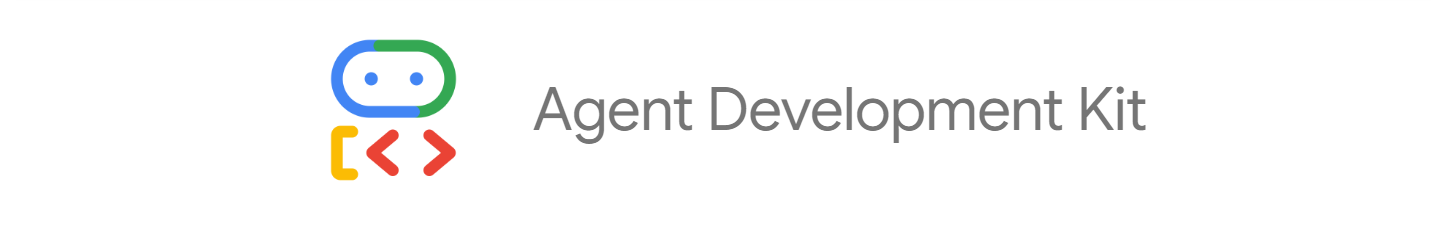

---

## Module 7: Introduction to Conversational Context: Session, State, and Memory 👉 [Click Here](https://google.github.io/adk-docs/sessions/)

---

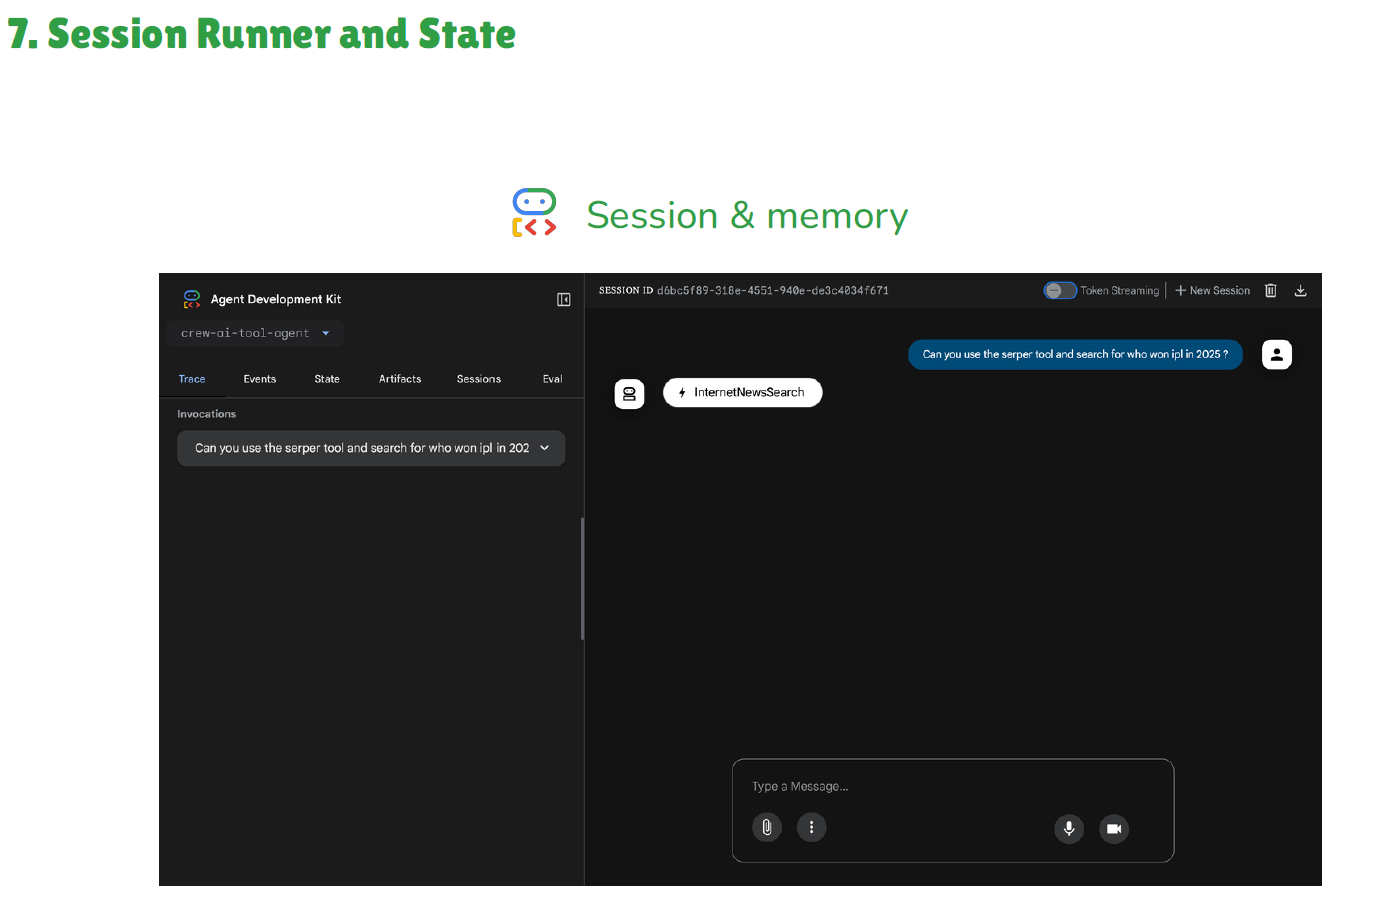

---

## Why Context Matters
Meaningful, multi-turn conversations require agents to understand context. Just like humans, they need to recall the conversation history: what's been said and done to maintain continuity and avoid repetition. The Agent Development Kit (ADK) provides structured ways to manage this context through `Session`, `State`, and `Memory`.

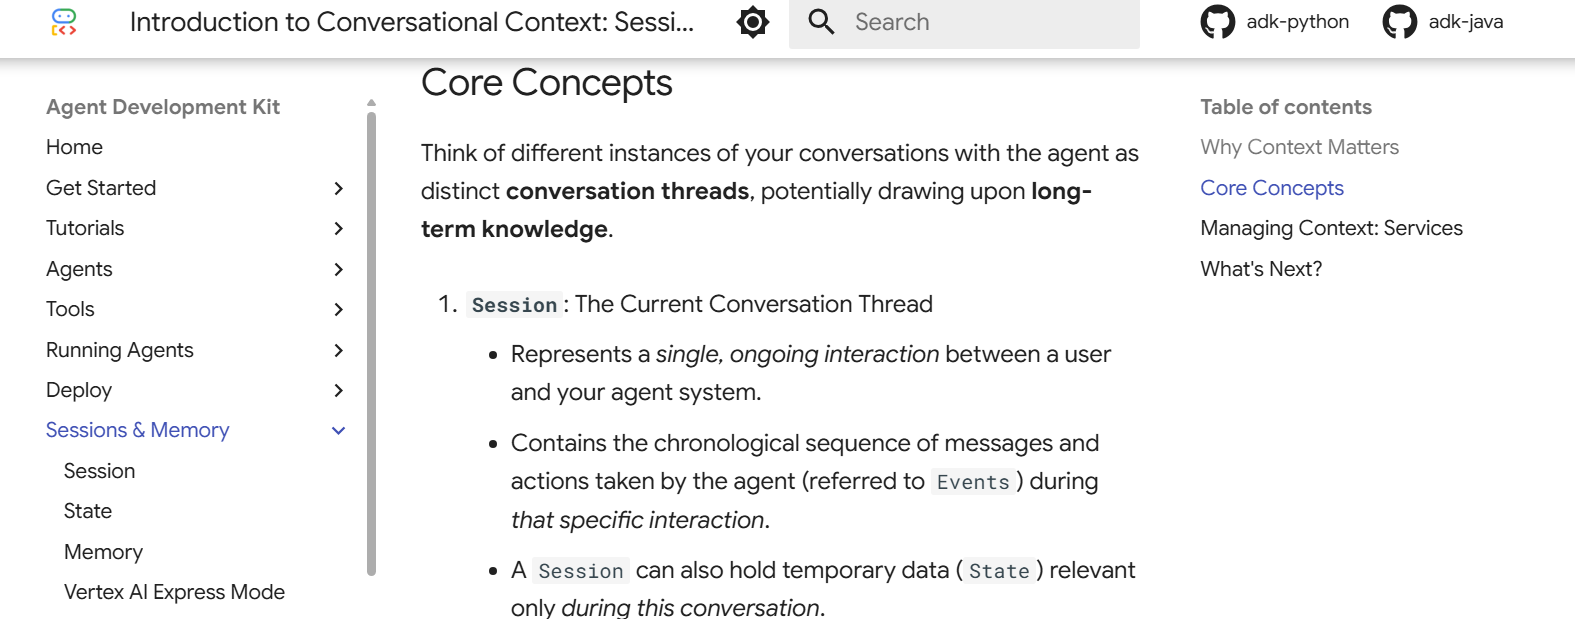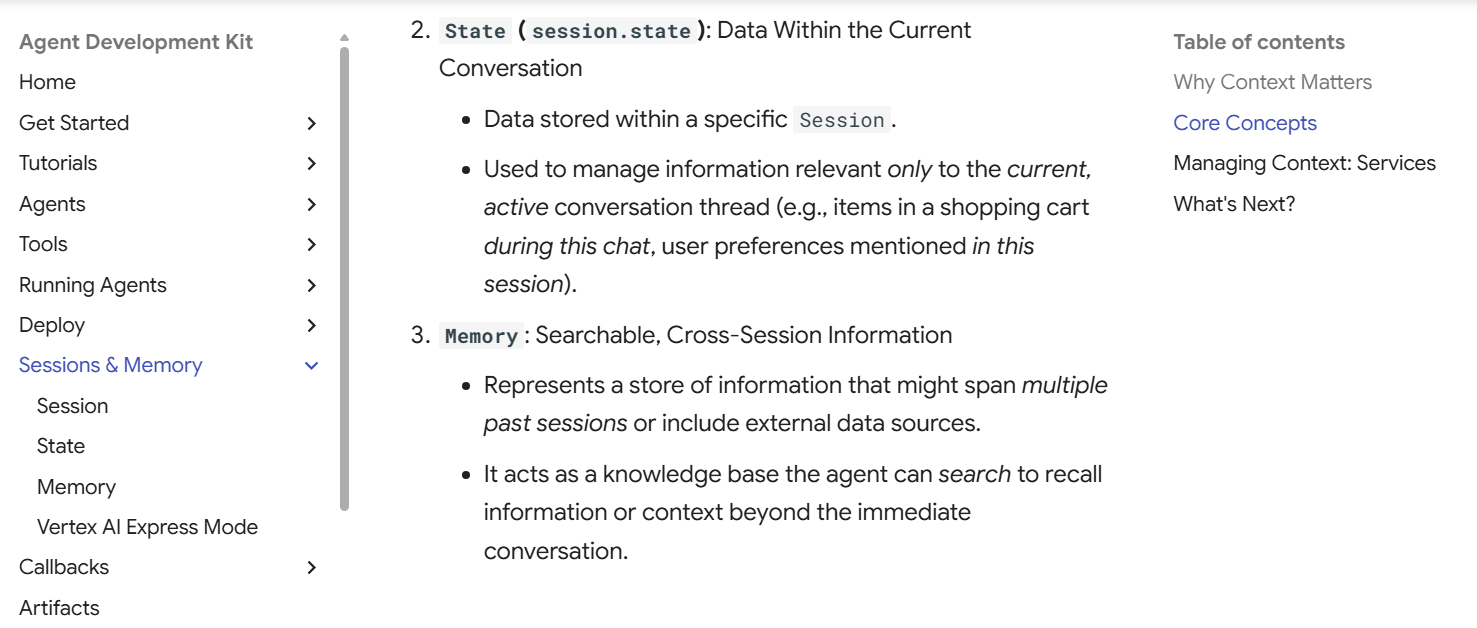

<br>

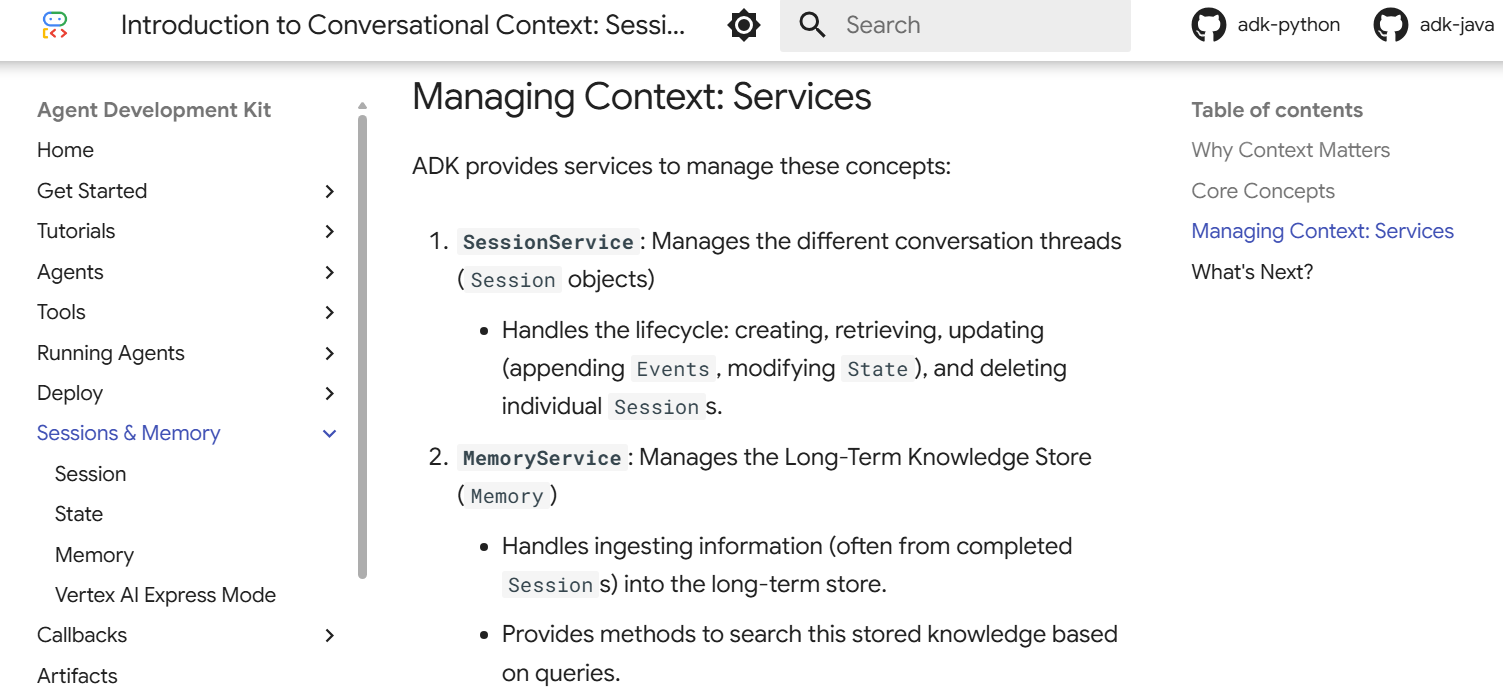

<br>

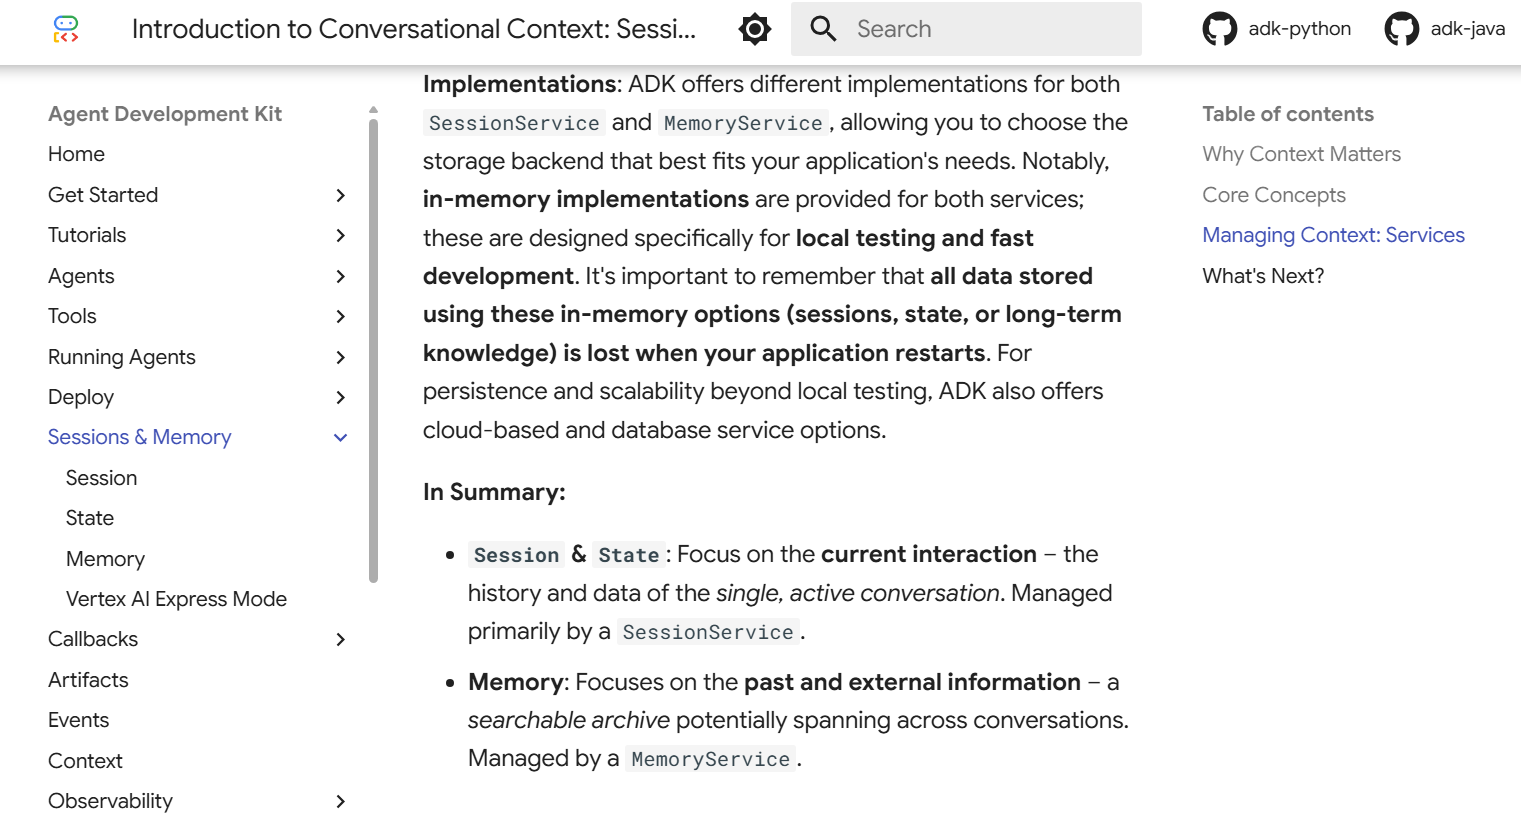

<hr>


## ChatGpt - Maintain Session, State and Memory
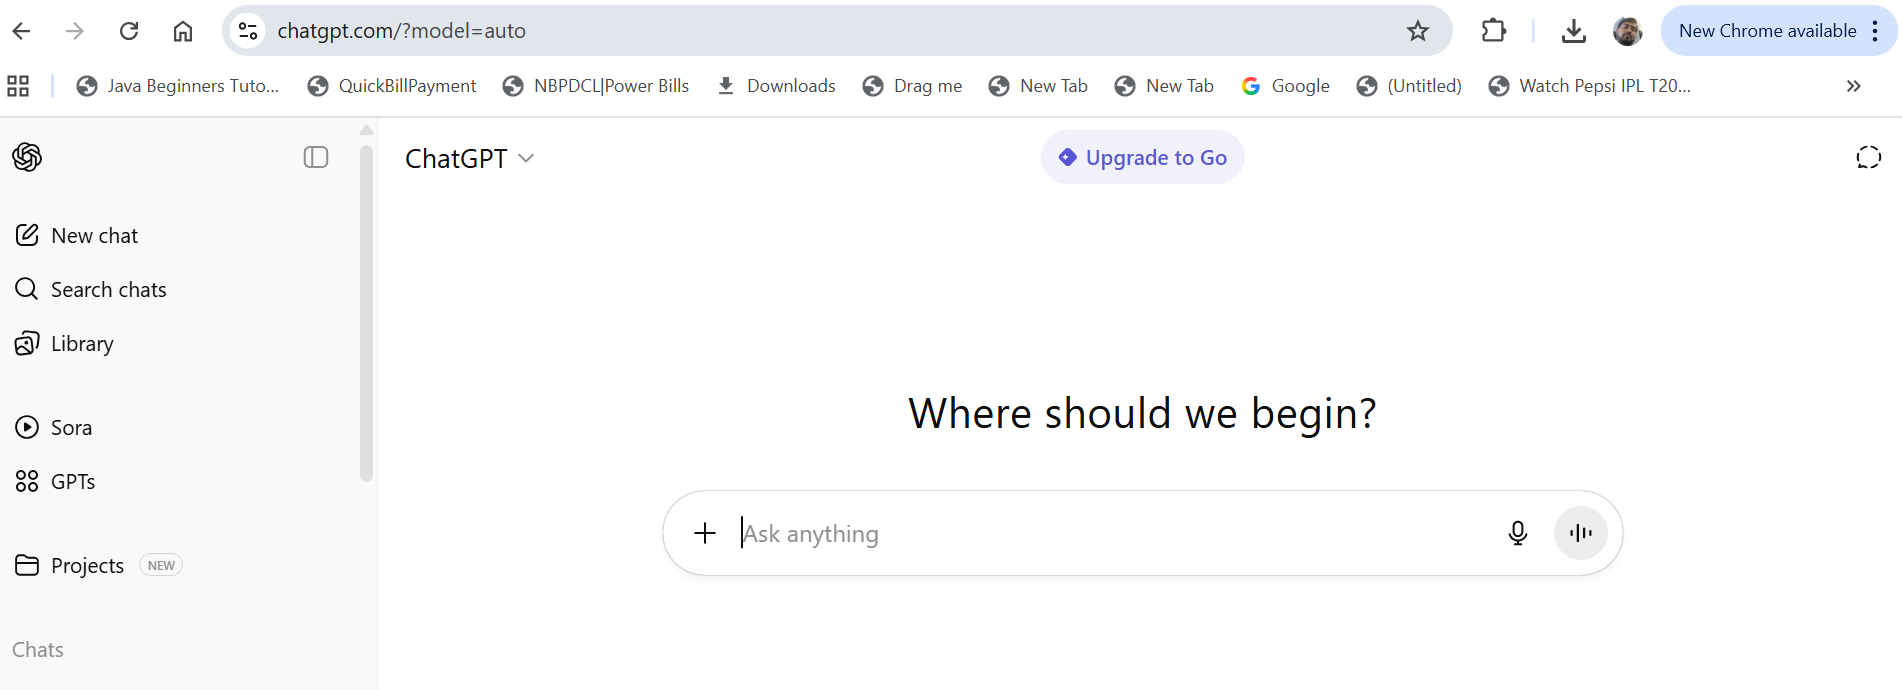 

### `Session -> Higlighed session_id`
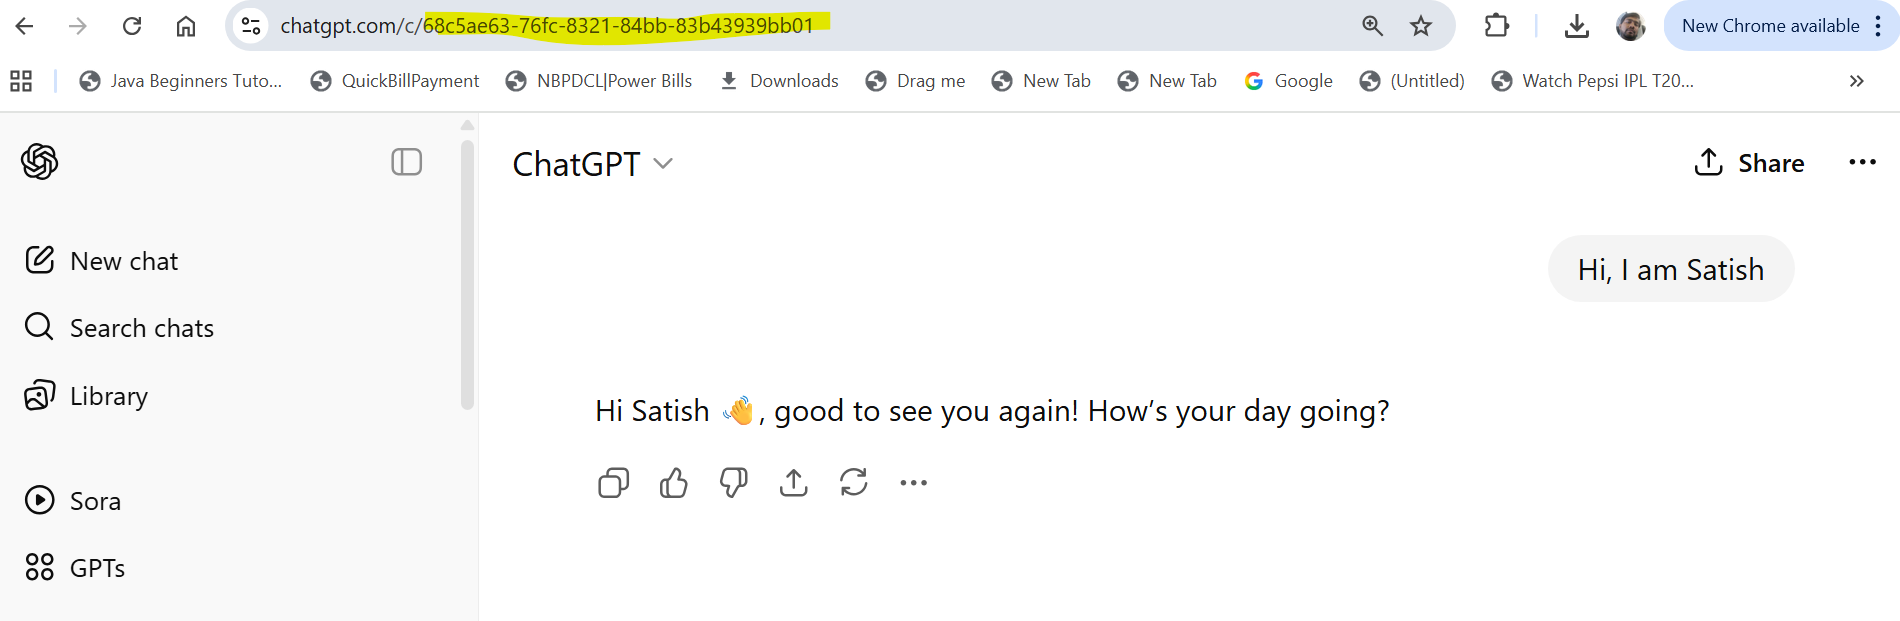 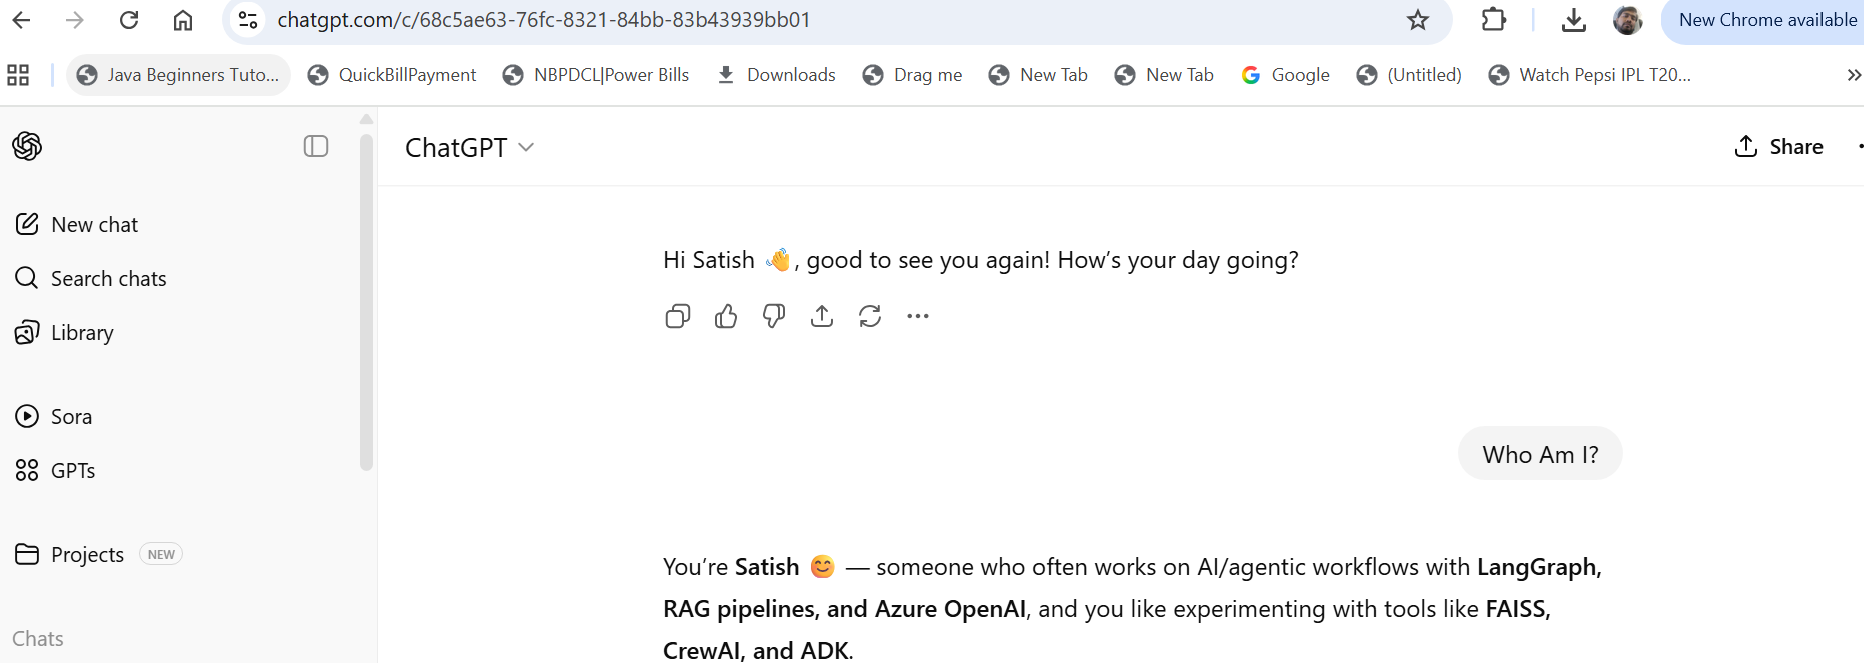 

### `Memory`
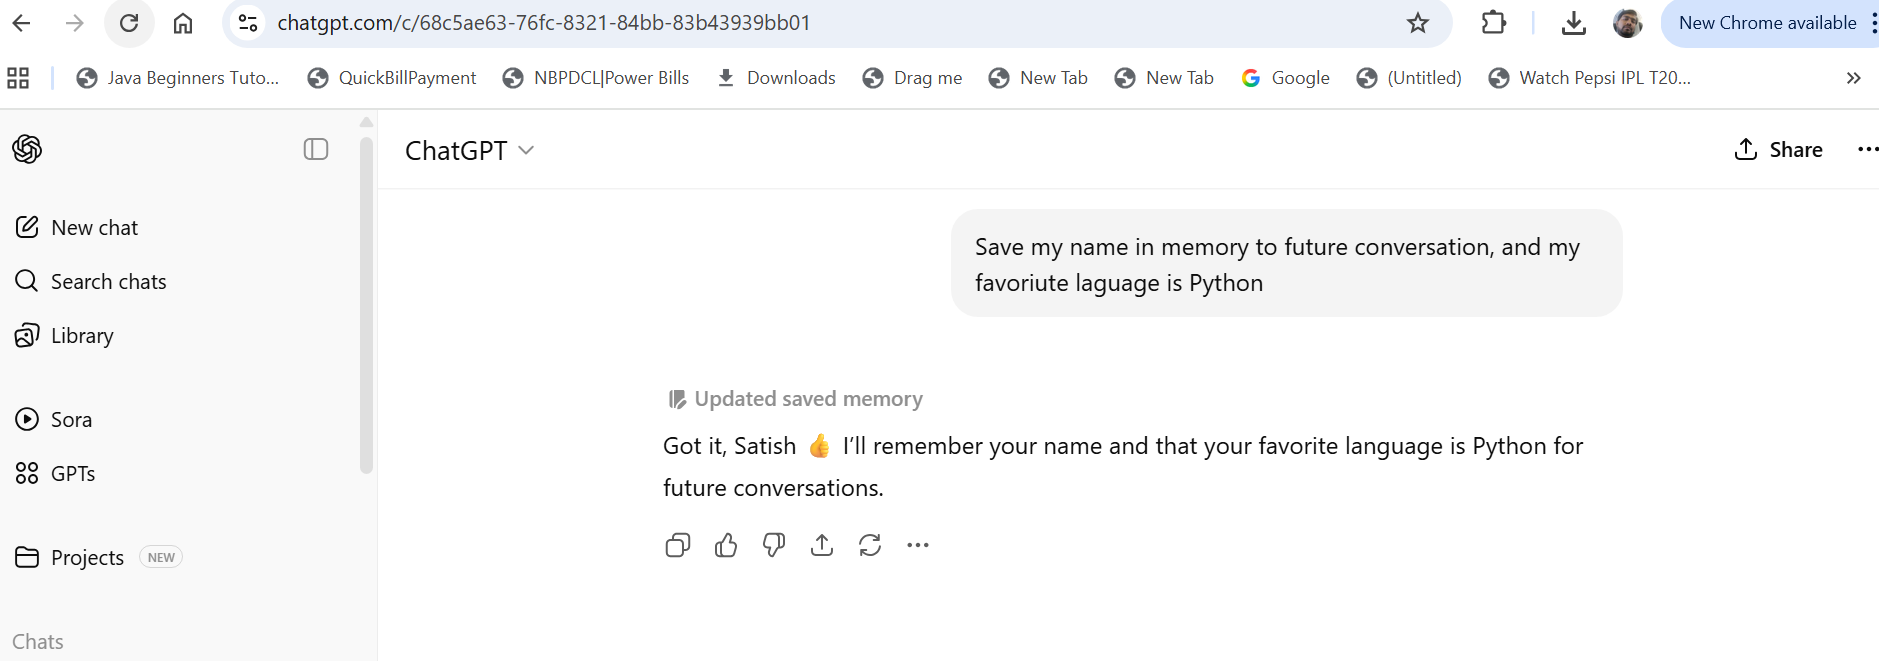 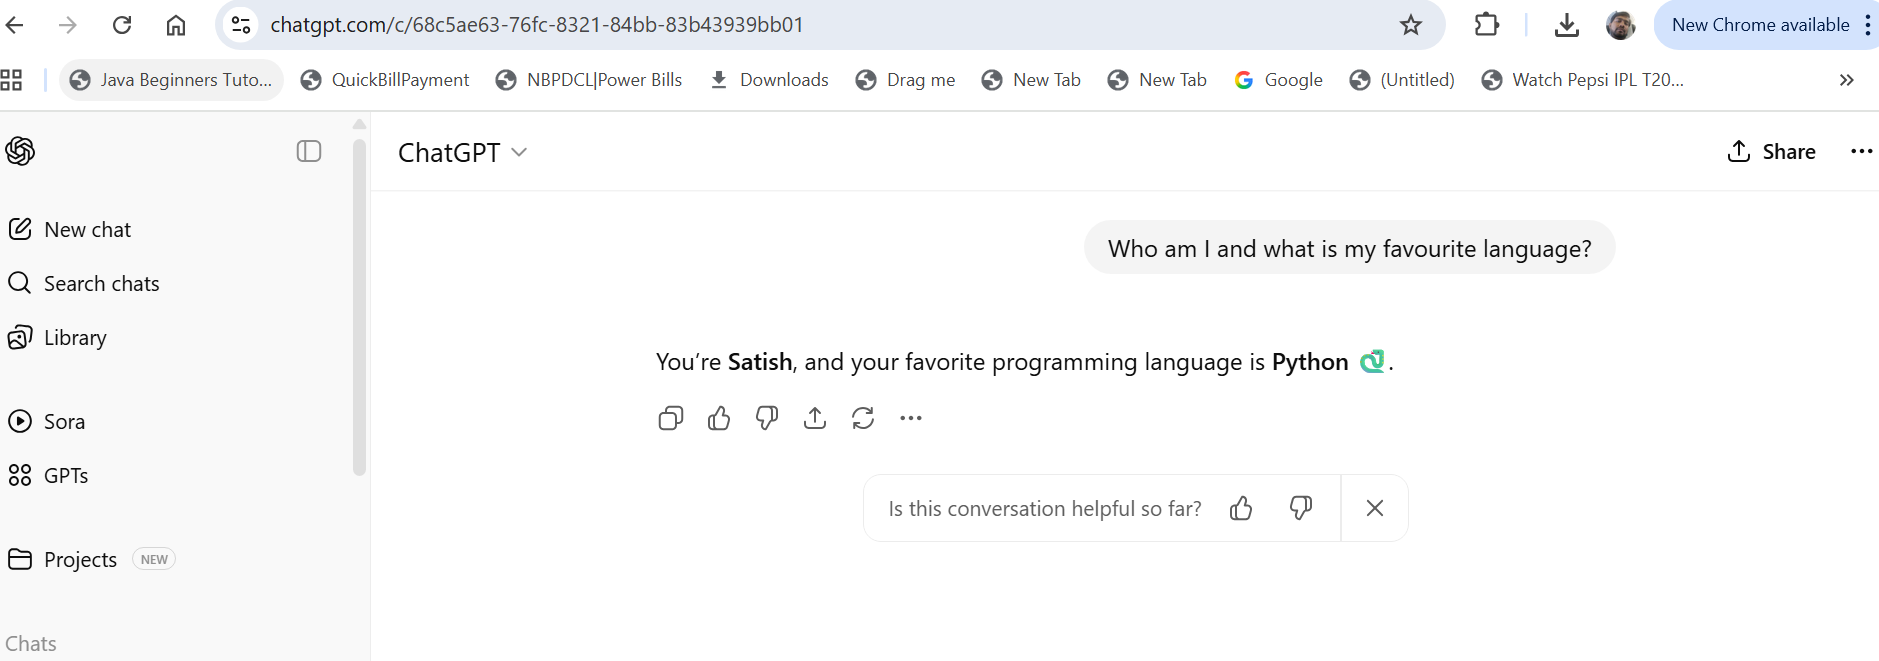 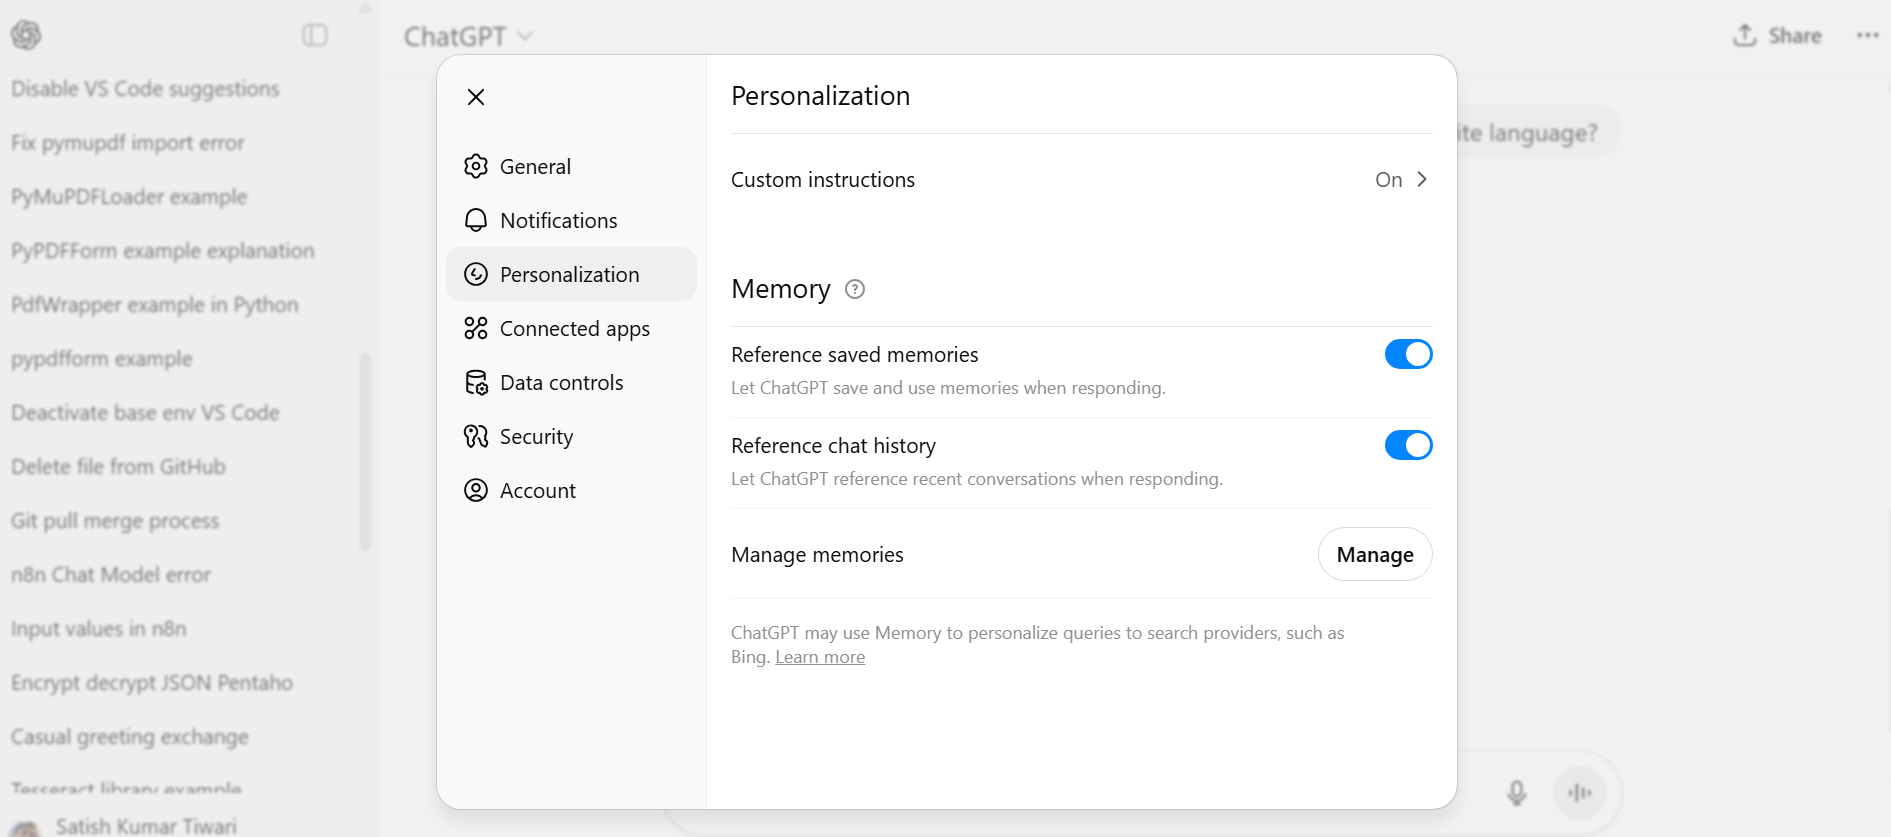

### `ChatGpt is recalling me even with session_id`
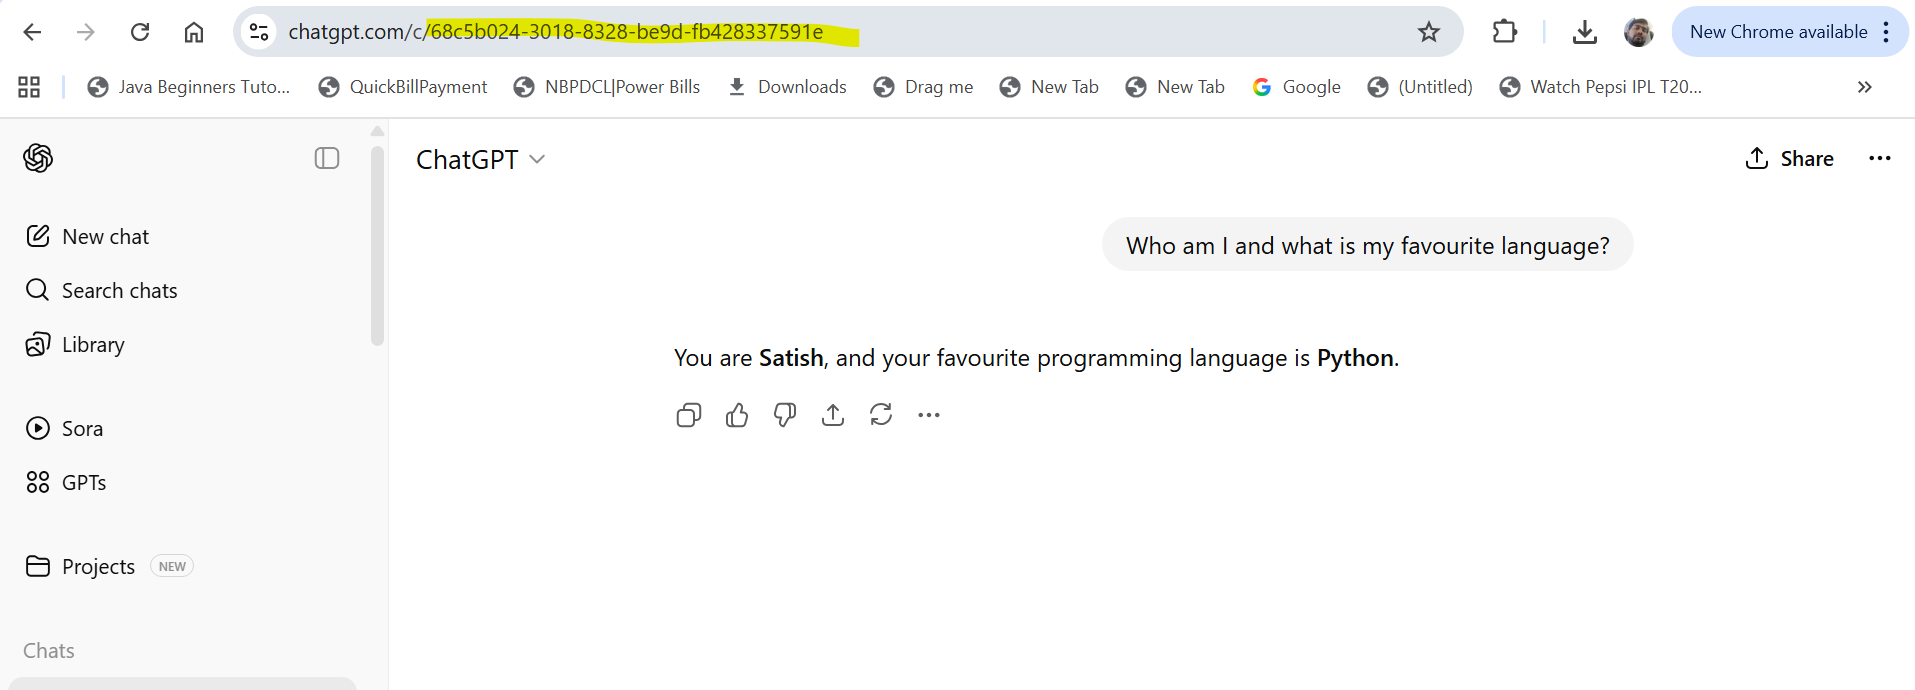

<hr>




## Session: Tracking Individual Conversations 👉 [Click Here](https://google.github.io/adk-docs/sessions/session/)

---

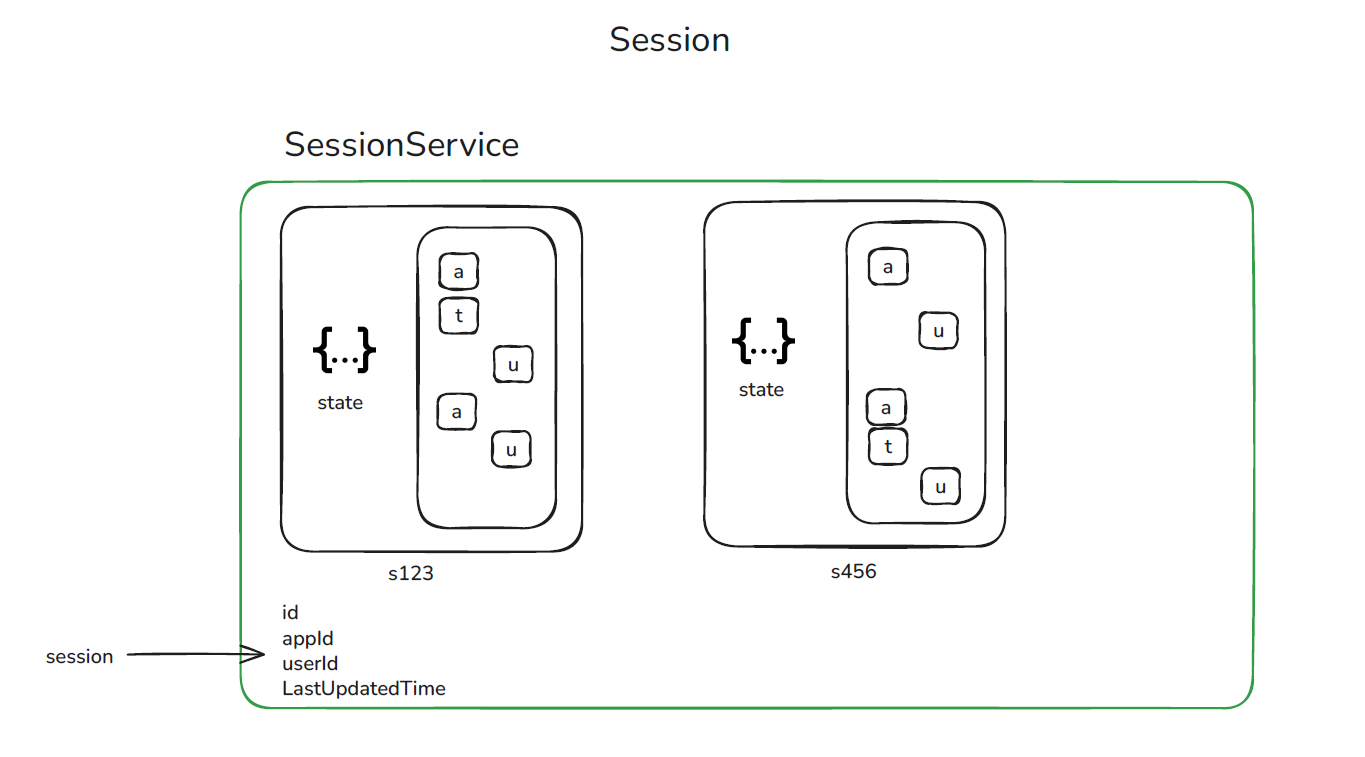 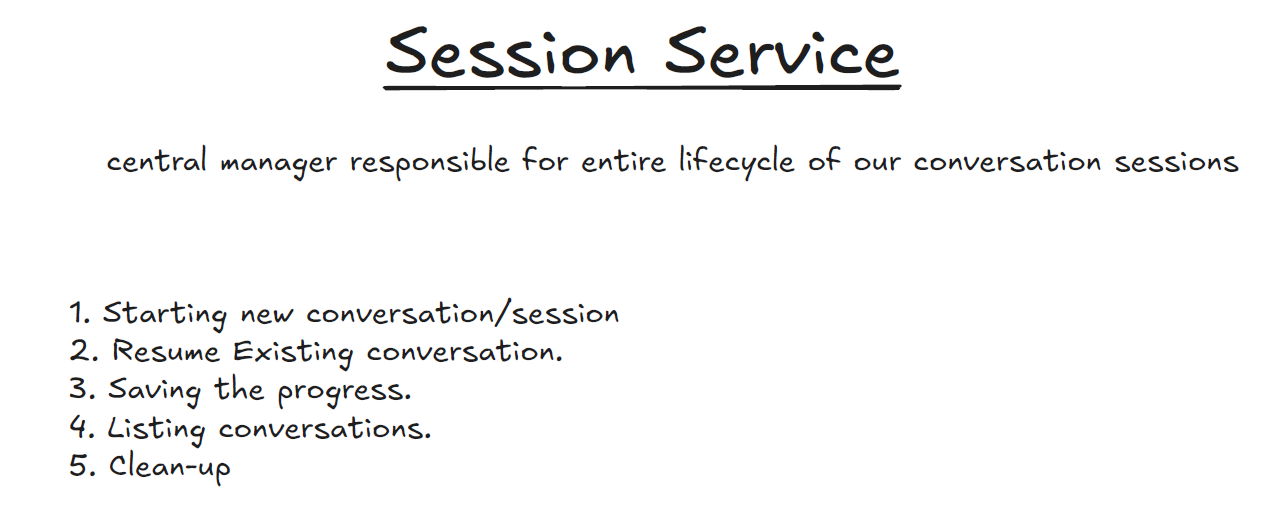 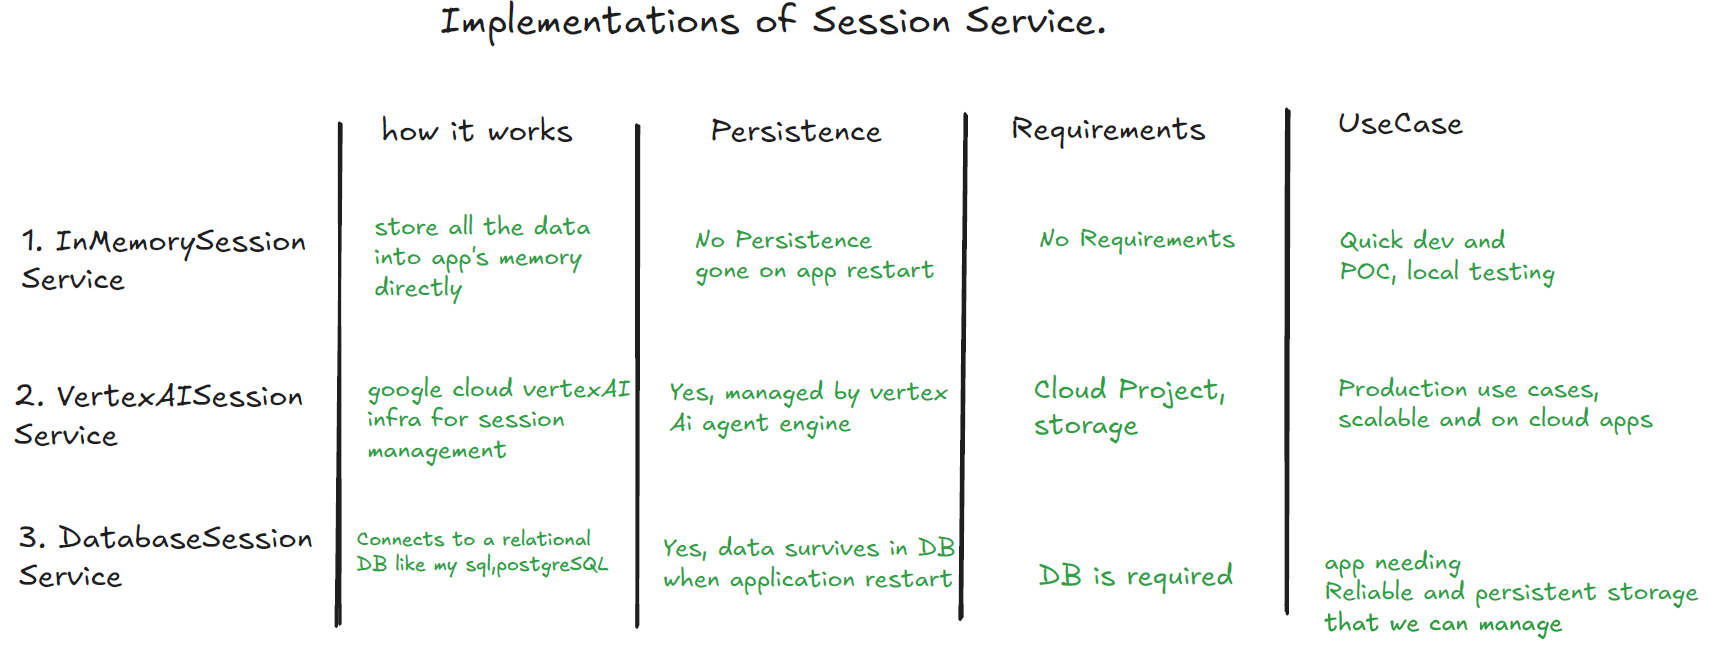

----

Following our Introduction, let's dive into the `Session`. Think back to the idea of a "conversation thread." Just like you wouldn't start every text message from scratch, agents need context regarding the ongoing interaction. `Session` is the ADK object designed specifically to track and manage these individual conversation threads.

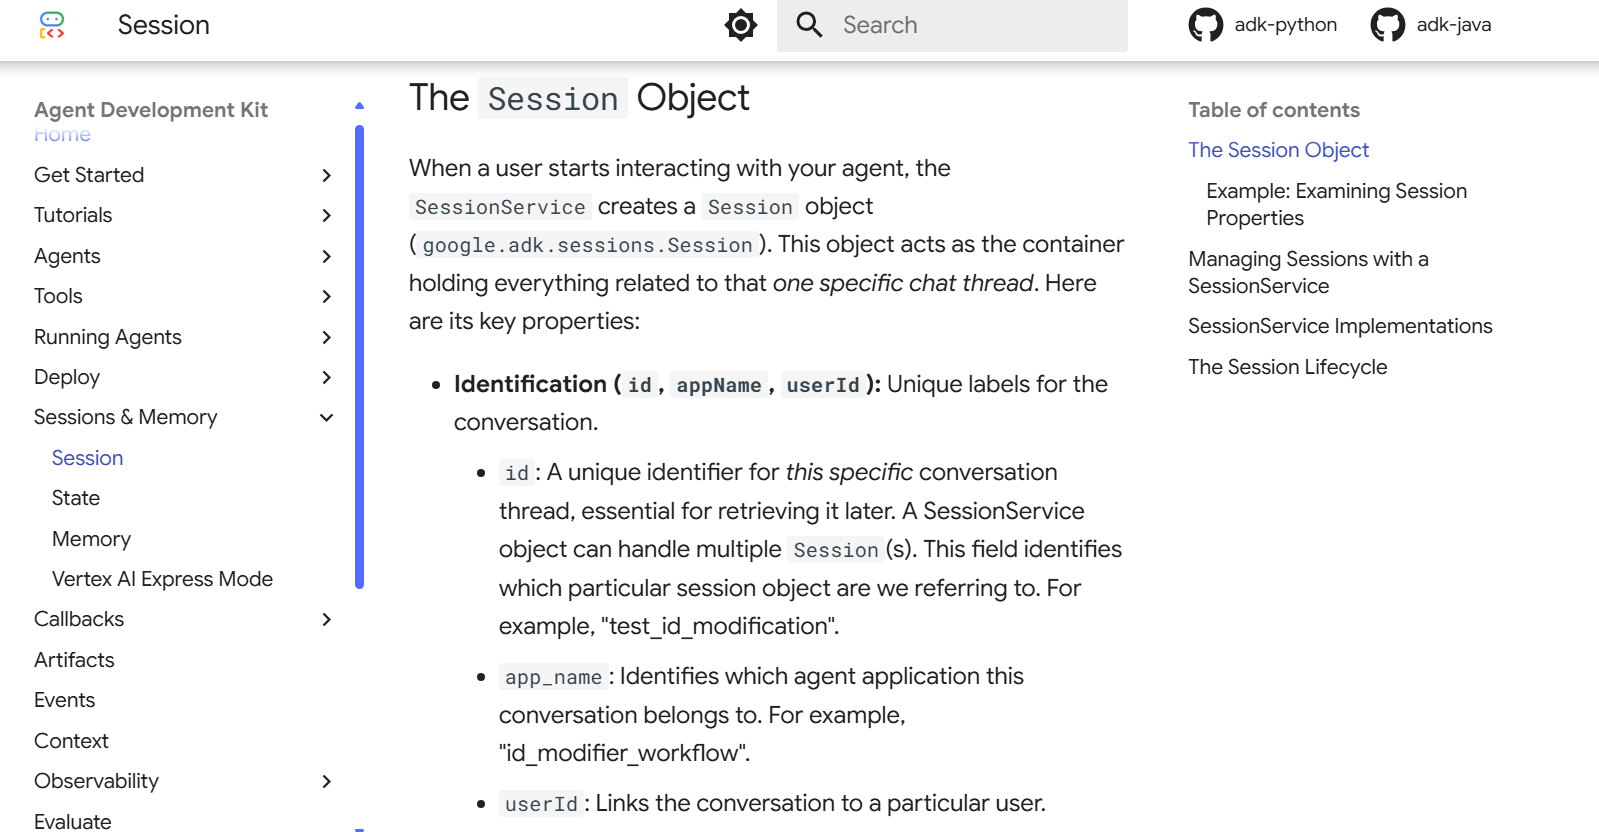 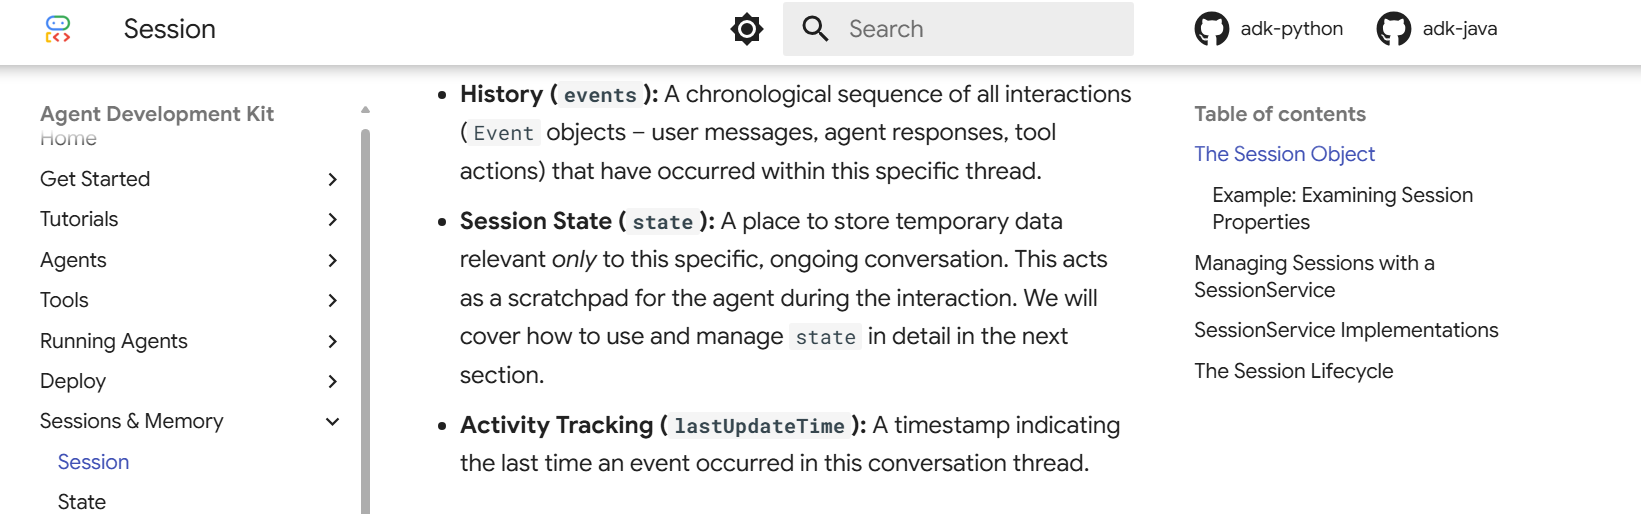

---

`Example: Examining Session Properties`
```Python
 from google.adk.sessions import InMemorySessionService, Session

 # Create a simple session to examine its properties
 temp_service = InMemorySessionService()
 example_session = await temp_service.create_session(
     app_name="my_app",
     user_id="example_user",
     state={"initial_key": "initial_value"} # State can be initialized
 )

 print(f"--- Examining Session Properties ---")
 print(f"ID (`id`):                {example_session.id}")
 print(f"Application Name (`app_name`): {example_session.app_name}")
 print(f"User ID (`user_id`):         {example_session.user_id}")
 print(f"State (`state`):           {example_session.state}") # Note: Only shows initial state here
 print(f"Events (`events`):         {example_session.events}") # Initially empty
 print(f"Last Update (`last_update_time`): {example_session.last_update_time:.2f}")
 print(f"---------------------------------")

 # Clean up (optional for this example)
 temp_service = await temp_service.delete_session(app_name=example_session.app_name,
                             user_id=example_session.user_id, session_id=example_session.id)
 print("The final status of temp_service - ", temp_service)
```
---

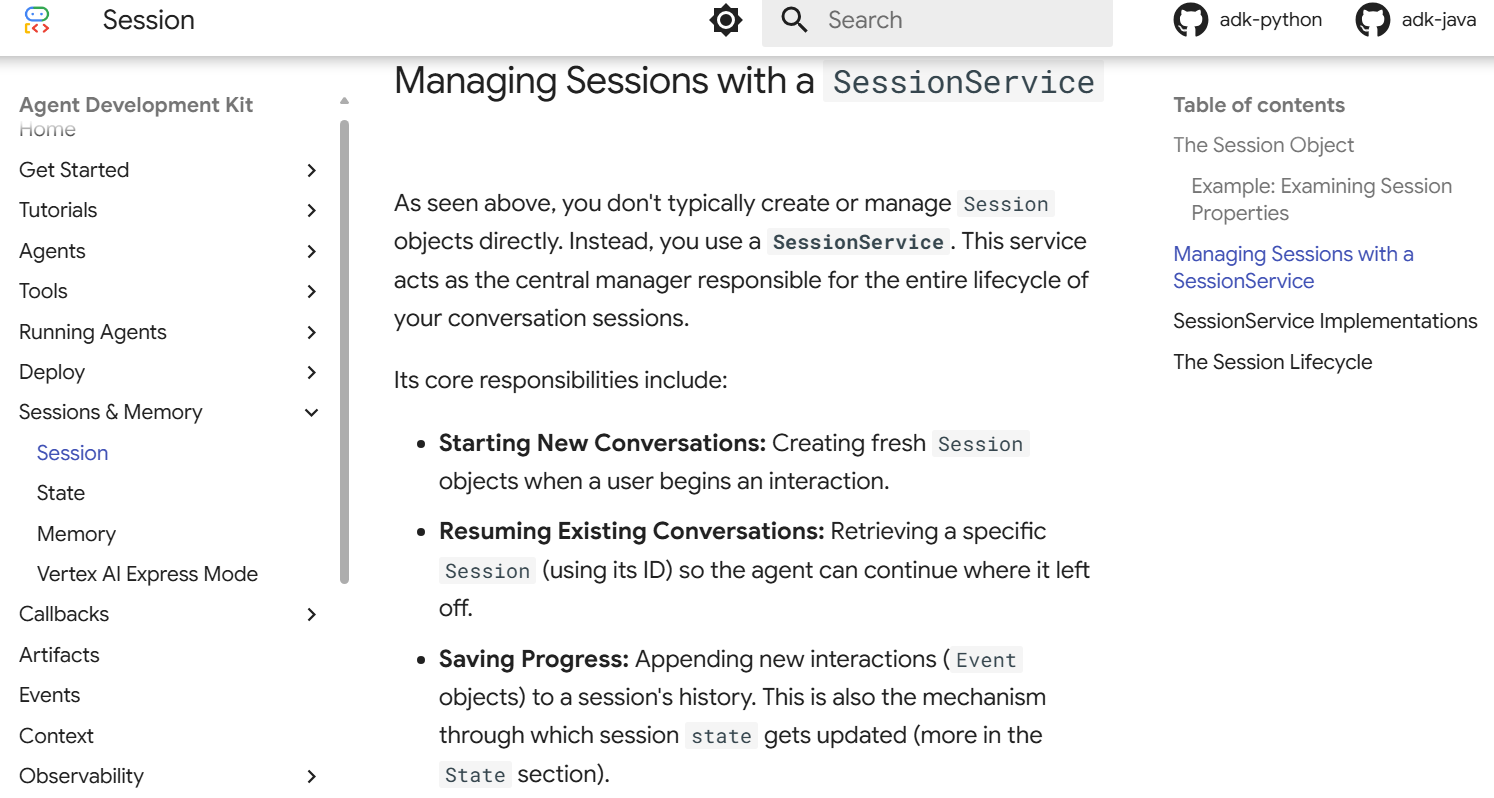 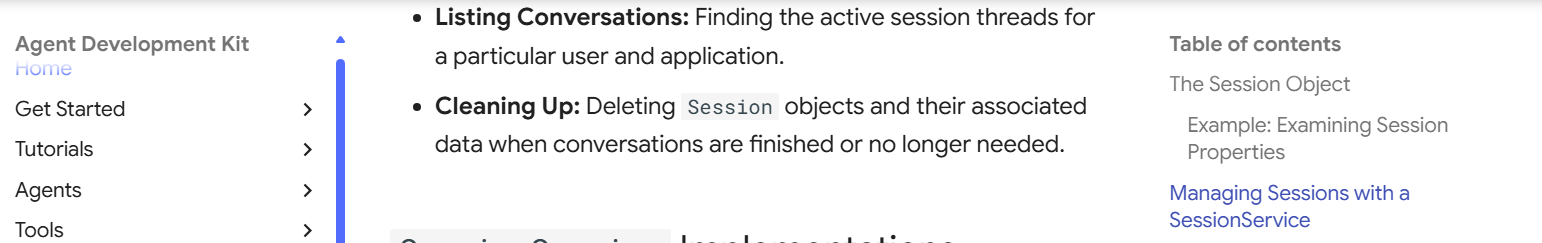
<br>
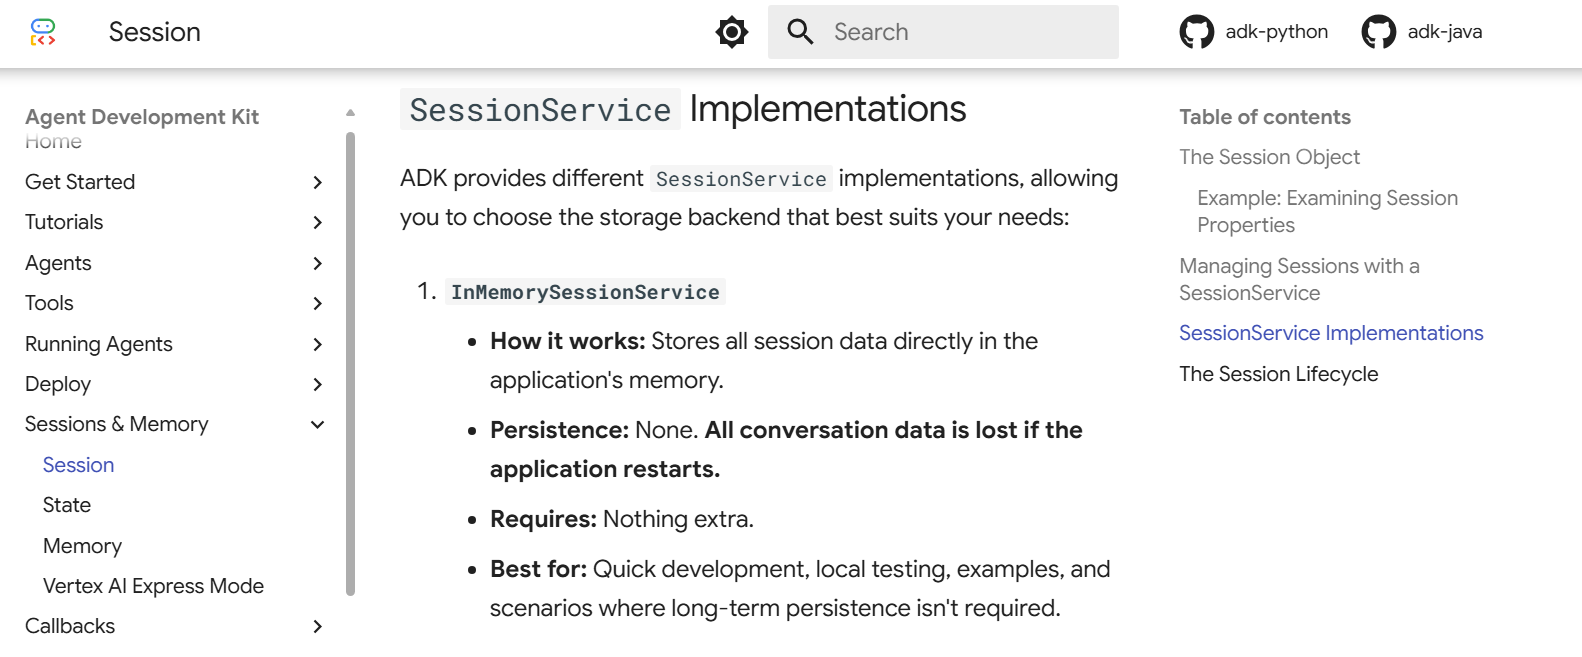 

---

```Python
 from google.adk.sessions import InMemorySessionService
 session_service = InMemorySessionService()
```
---
<br>

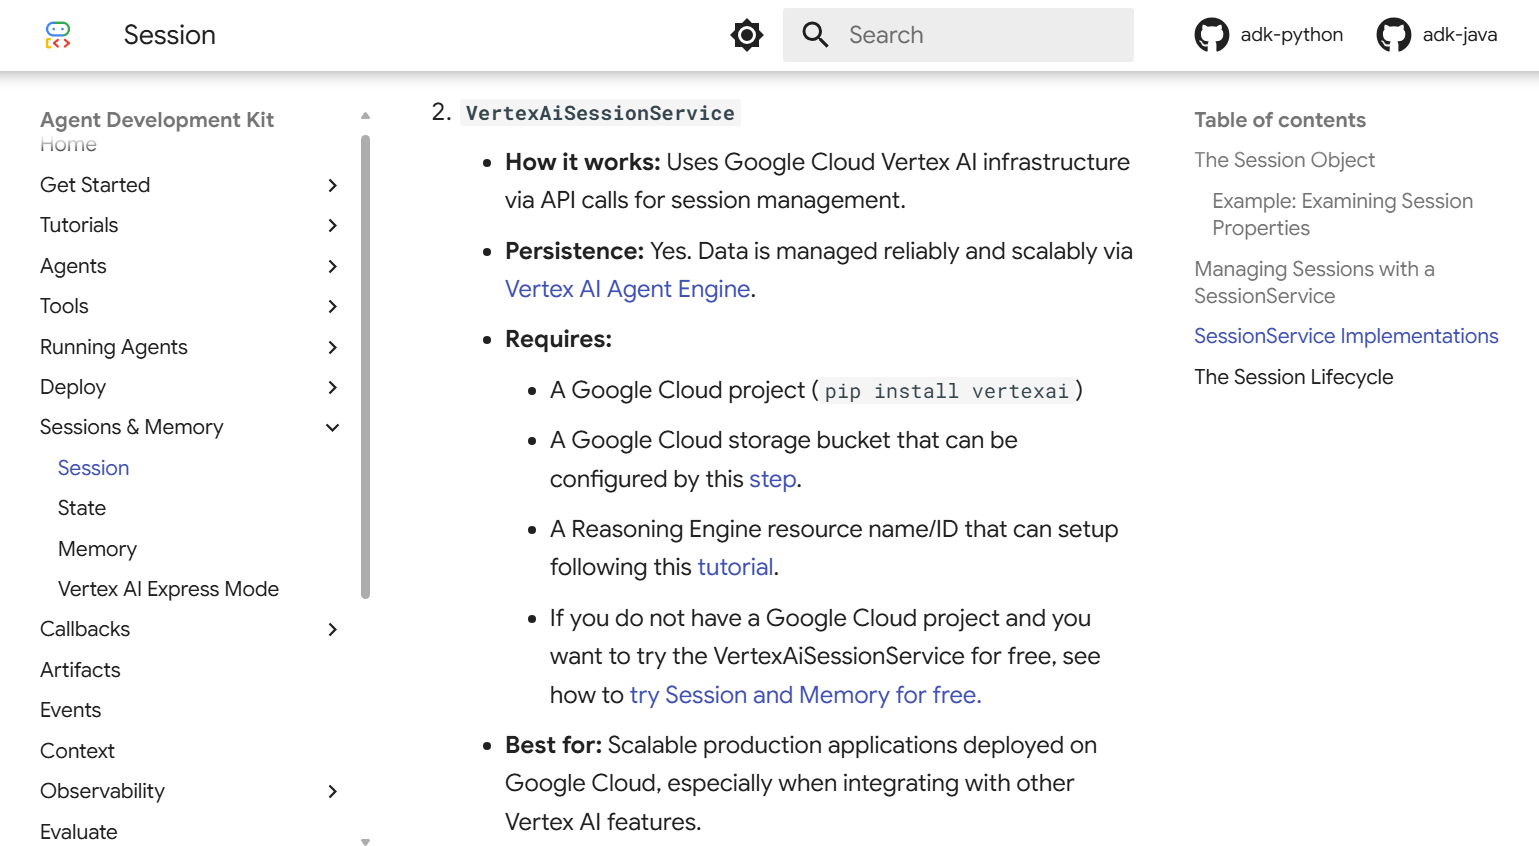

---
```Python
# Requires: pip install google-adk[vertexai]
# Plus GCP setup and authentication
from google.adk.sessions import VertexAiSessionService

PROJECT_ID = "your-gcp-project-id"
LOCATION = "us-central1"
# The app_name used with this service should be the Reasoning Engine ID or name
REASONING_ENGINE_APP_NAME = "projects/your-gcp-project-id/locations/us-central1/reasoningEngines/your-engine-id"

session_service = VertexAiSessionService(project=PROJECT_ID, location=LOCATION)
# Use REASONING_ENGINE_APP_NAME when calling service methods, e.g.:
# session_service = await session_service.create_session(app_name=REASONING_ENGINE_APP_NAME, ...)
```

---
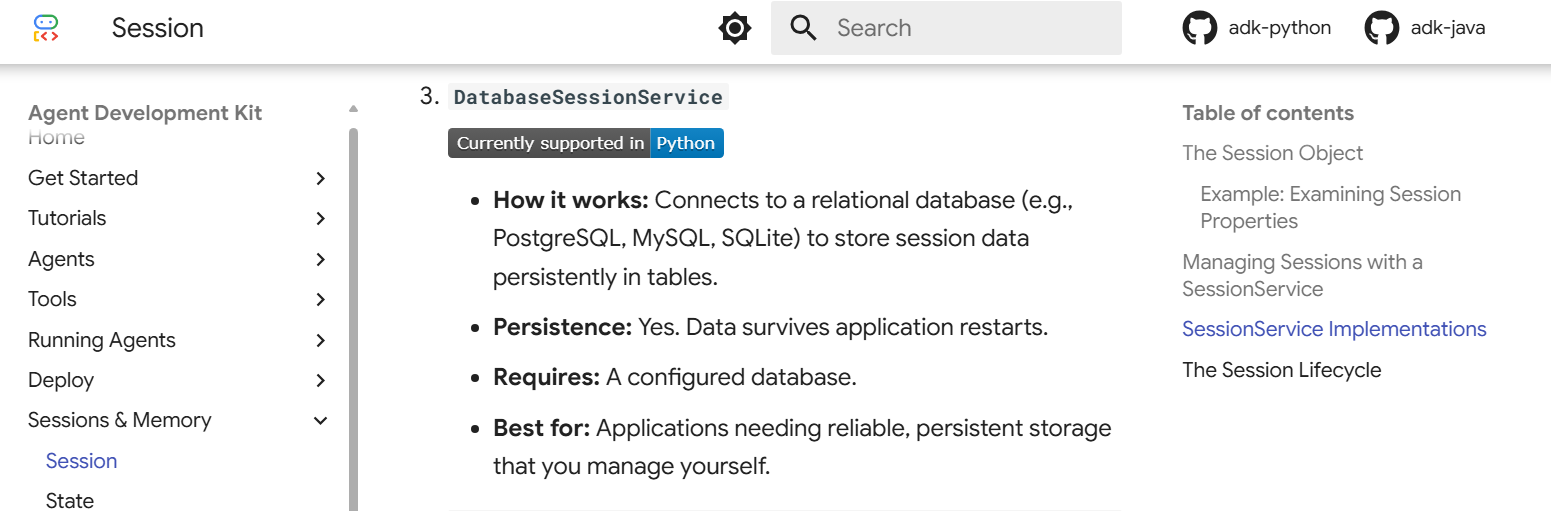

---
```Python
from google.adk.sessions import DatabaseSessionService
# Example using a local SQLite file:
db_url = "sqlite:///./my_agent_data.db"
session_service = DatabaseSessionService(db_url=db_url)
```

----
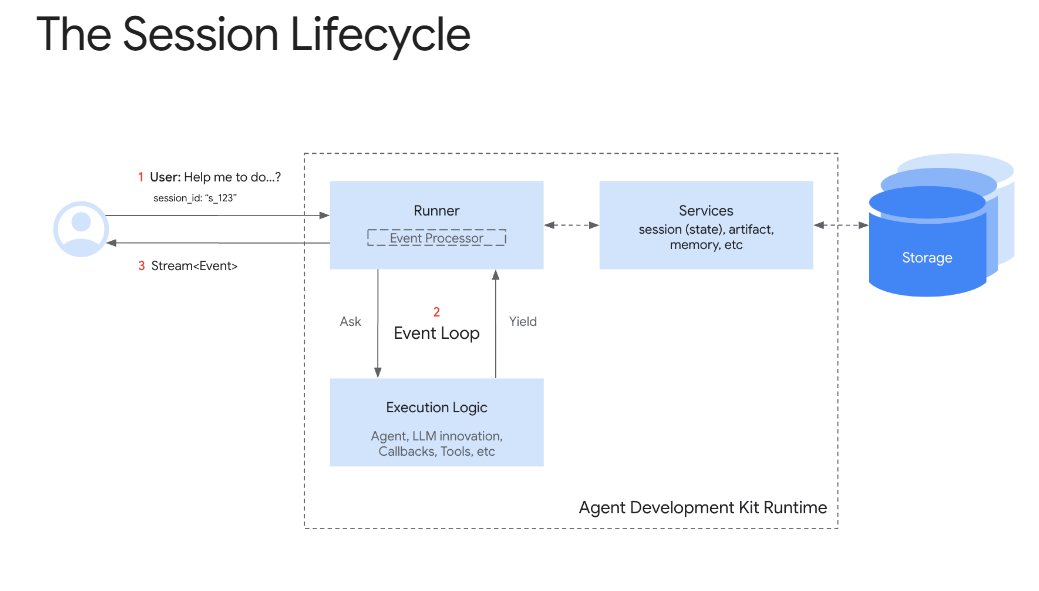
<br>
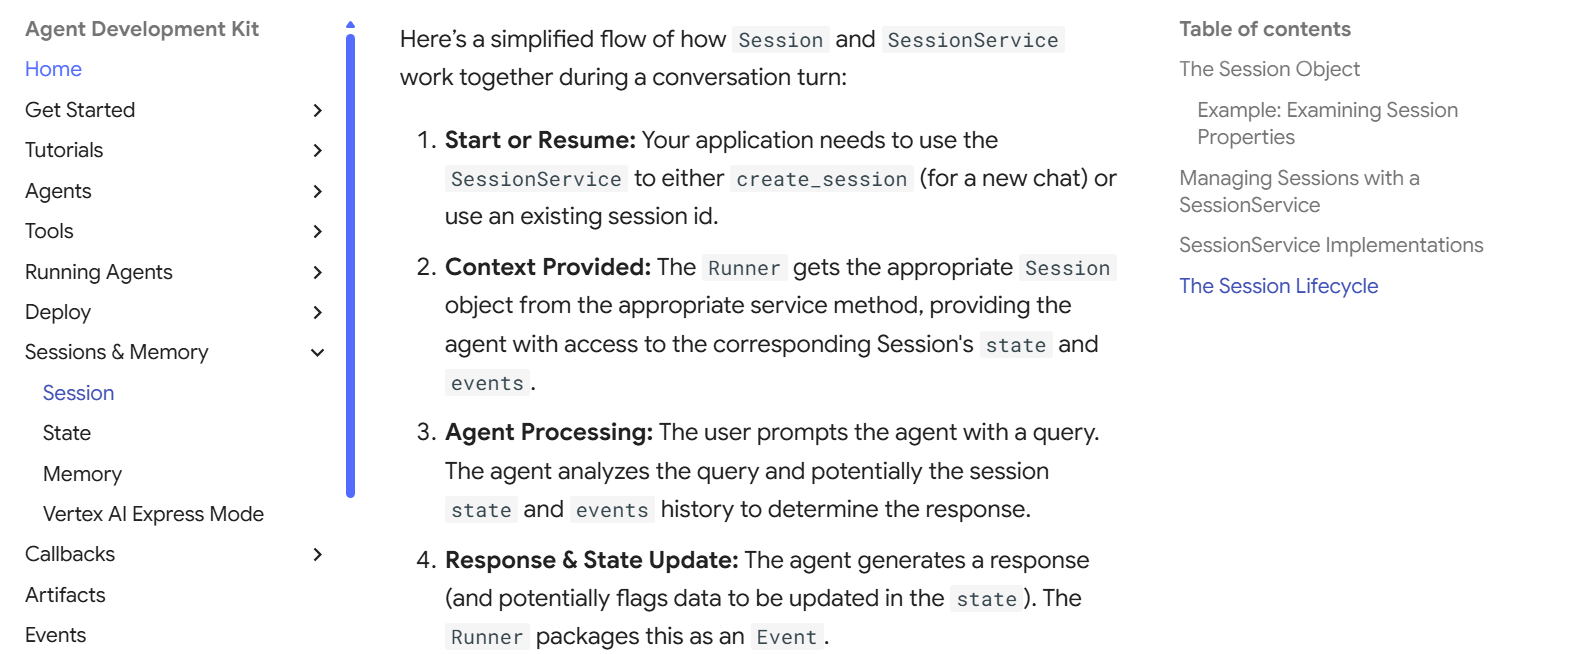 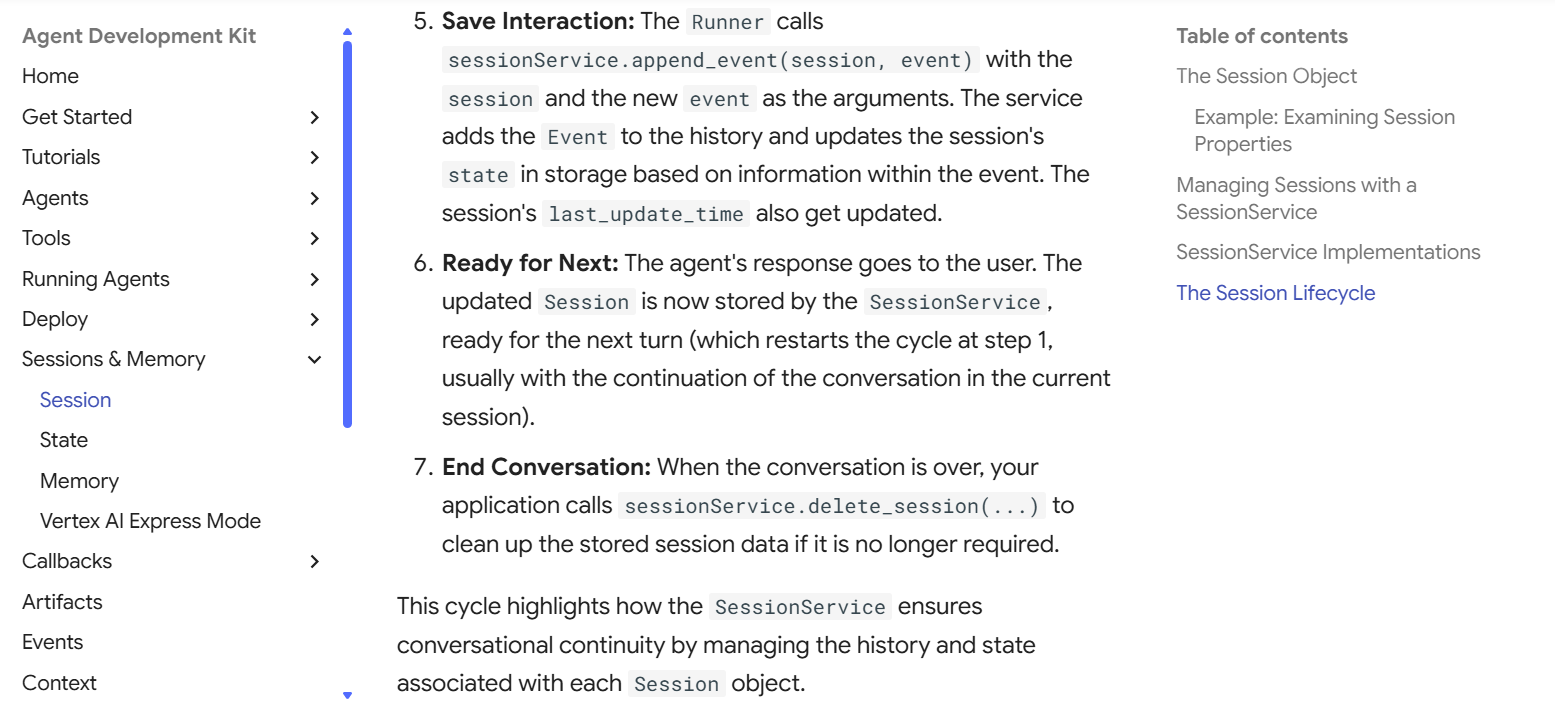

---

## State: The Session's Scratchpad 👉 [Click Here](https://google.github.io/adk-docs/sessions/state/)

----

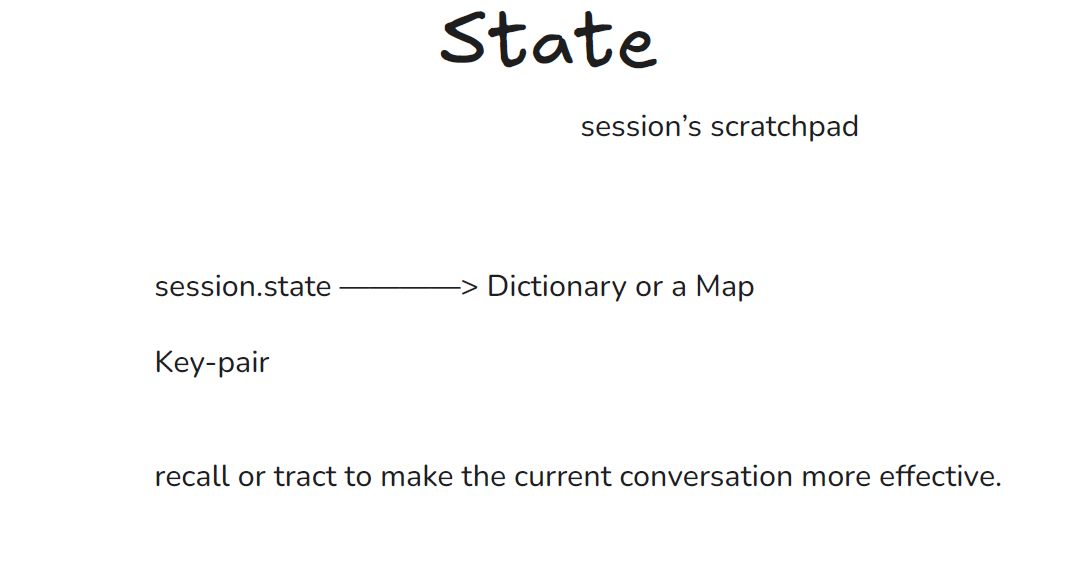 <br> 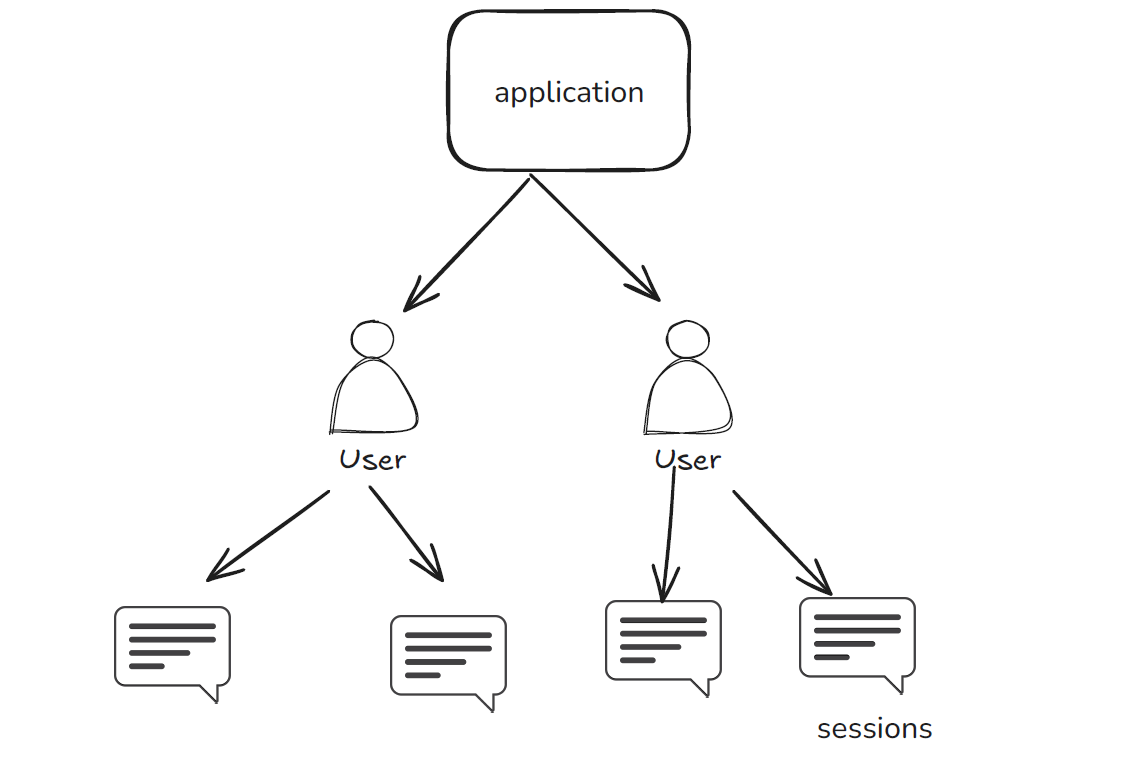 <br> 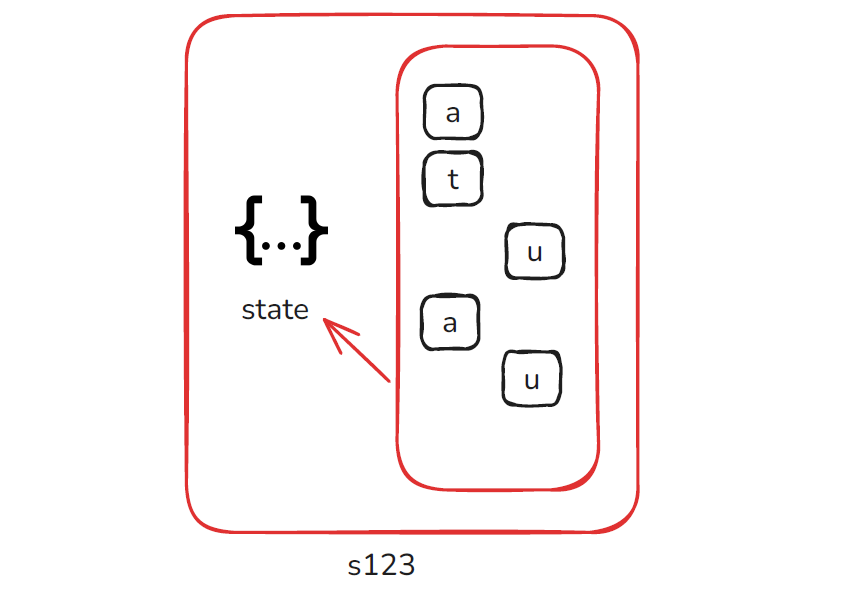

----

Within each `Session` (our conversation thread), the state attribute acts like the agent's dedicated scratchpad for that specific interaction. While `session.events` holds the full history, `session.state` is where the agent stores and updates dynamic details needed during the conversation.

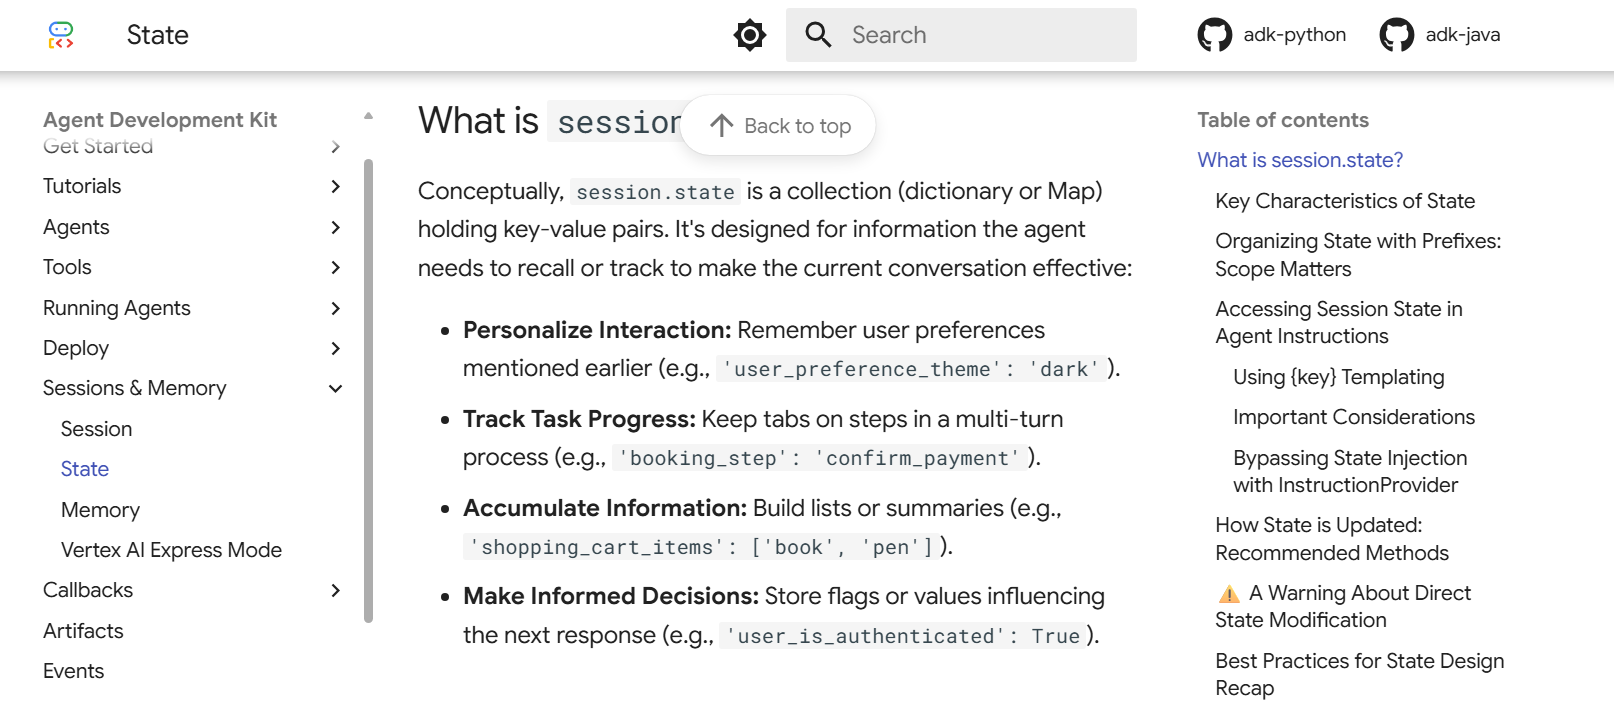 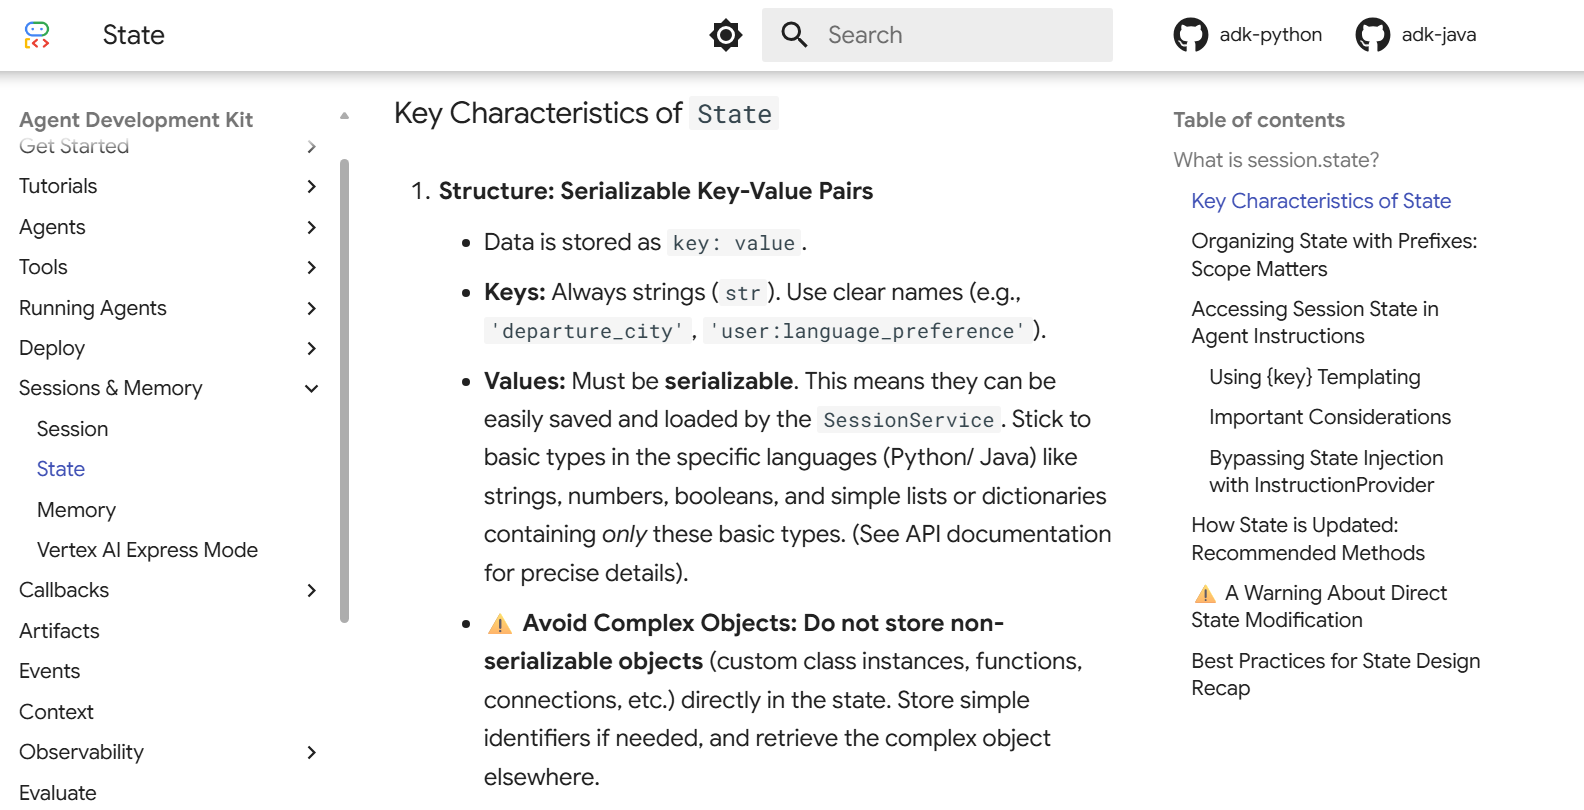 
<br><br>

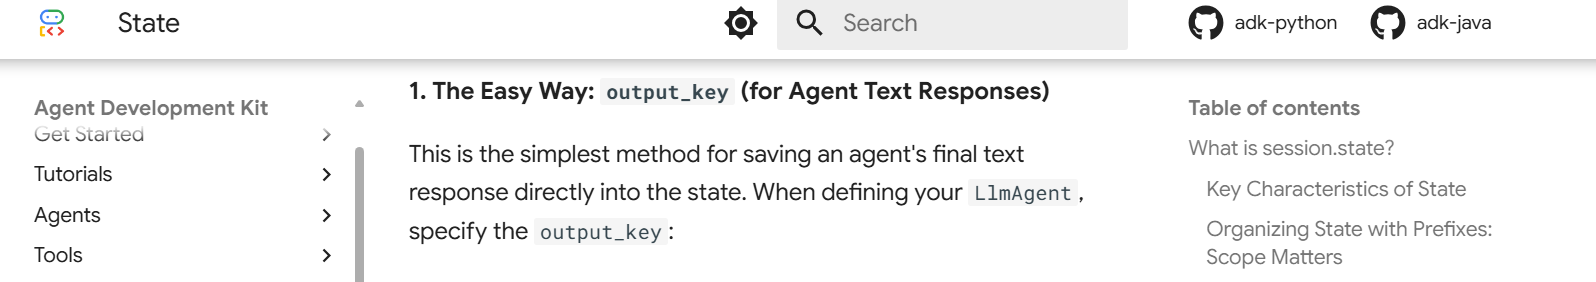

---

```Python
from google.adk.agents import LlmAgent
from google.adk.sessions import InMemorySessionService, Session
from google.adk.runners import Runner
from google.genai.types import Content, Part

# Define agent with output_key
greeting_agent = LlmAgent(
    name="Greeter",
    model="gemini-2.0-flash", # Use a valid model
    instruction="Generate a short, friendly greeting.",
    output_key="last_greeting" # Save response to state['last_greeting']
)

# --- Setup Runner and Session ---
app_name, user_id, session_id = "state_app", "user1", "session1"
session_service = InMemorySessionService()
runner = Runner(
    agent=greeting_agent,
    app_name=app_name,
    session_service=session_service
)
session = await session_service.create_session(app_name=app_name,
                                    user_id=user_id,
                                    session_id=session_id)
print(f"Initial state: {session.state}")

# --- Run the Agent ---
# Runner handles calling append_event, which uses the output_key
# to automatically create the state_delta.
user_message = Content(parts=[Part(text="Hello")])
for event in runner.run(user_id=user_id,
                        session_id=session_id,
                        new_message=user_message):
    if event.is_final_response():
      print(f"Agent responded.") # Response text is also in event.content

# --- Check Updated State ---
updated_session = await session_service.get_session(app_name=APP_NAME, user_id=USER_ID, session_id=session_id)
print(f"State after agent run: {updated_session.state}")
# Expected output might include: {'last_greeting': 'Hello there! How can I help you today?'}
```

---

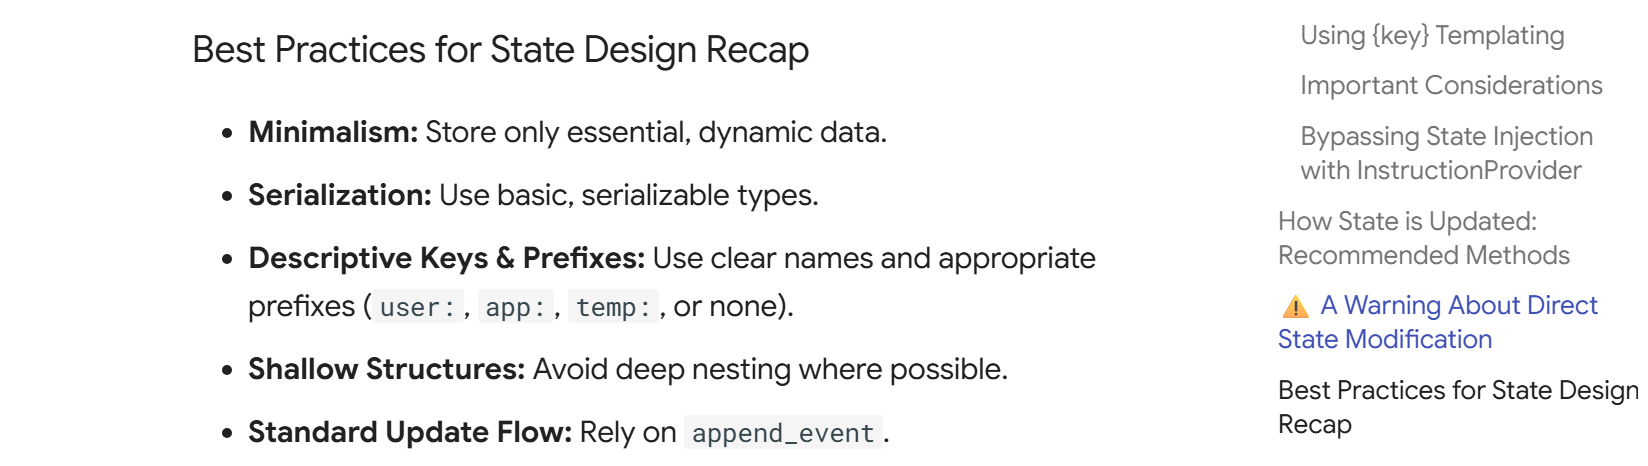

---

## Memory: Long-Term Knowledge with `MemoryService` 👉 [Click Here](https://google.github.io/adk-docs/sessions/memory/)
---
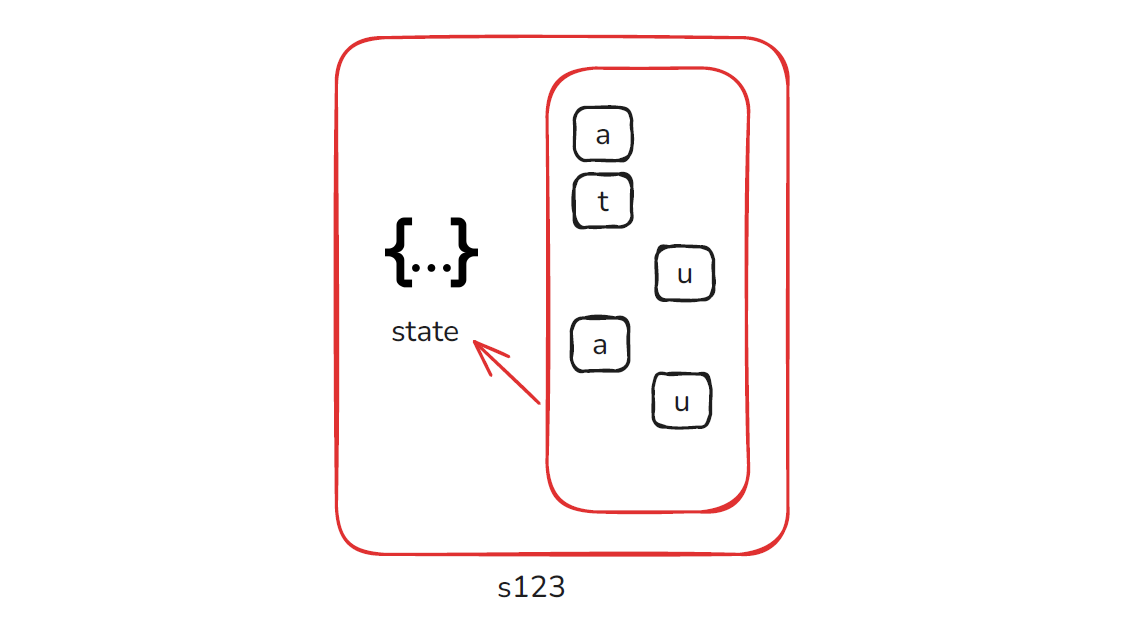

---
We've seen how `Session` tracks the history (`events`) and temporary data (`state`) for a ***single***, ongoing conversation. But what if an agent needs to recall information from past conversations or access external knowledge bases? This is where the concept of **Long-Term Knowledge** and the `MemoryService` come into play.

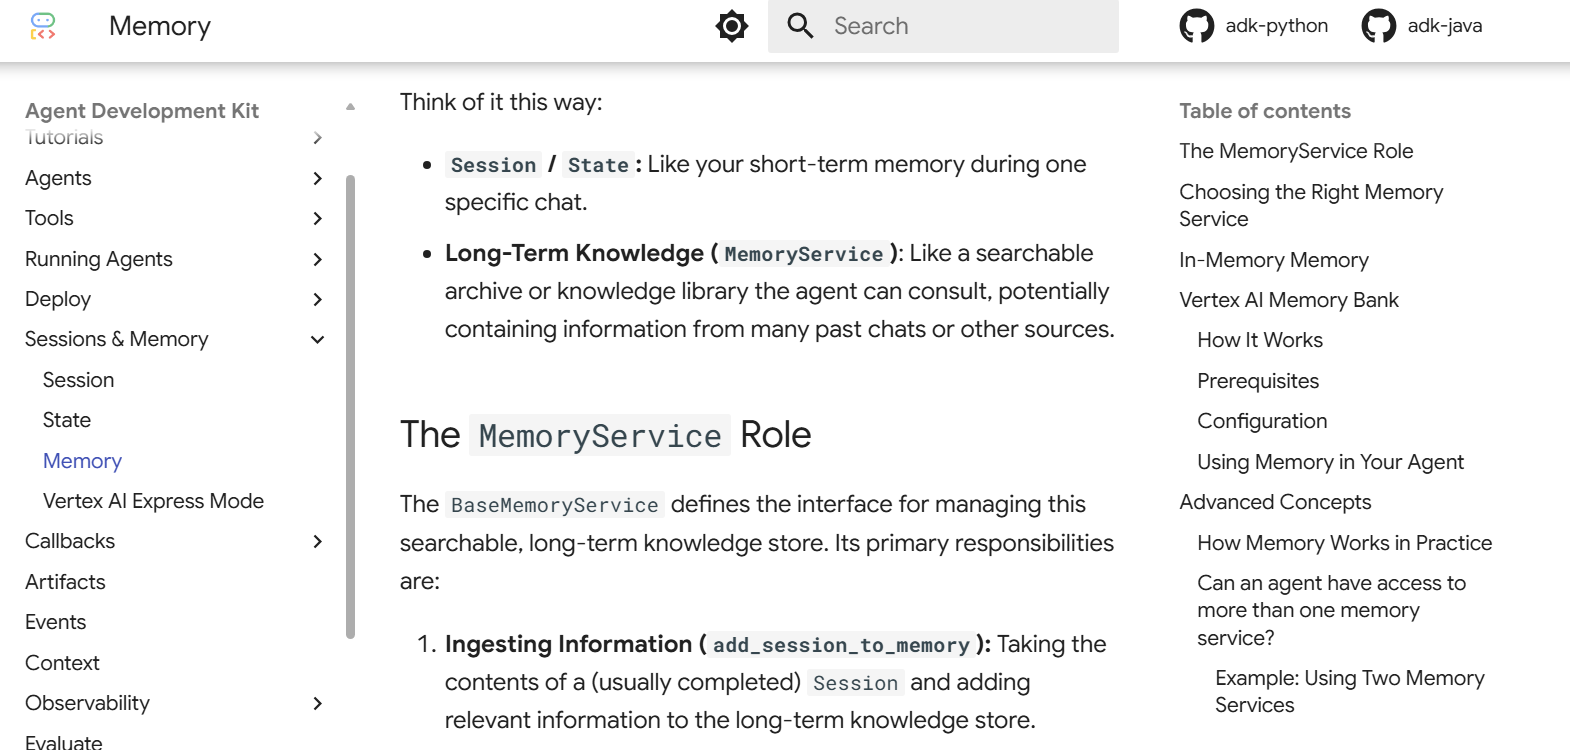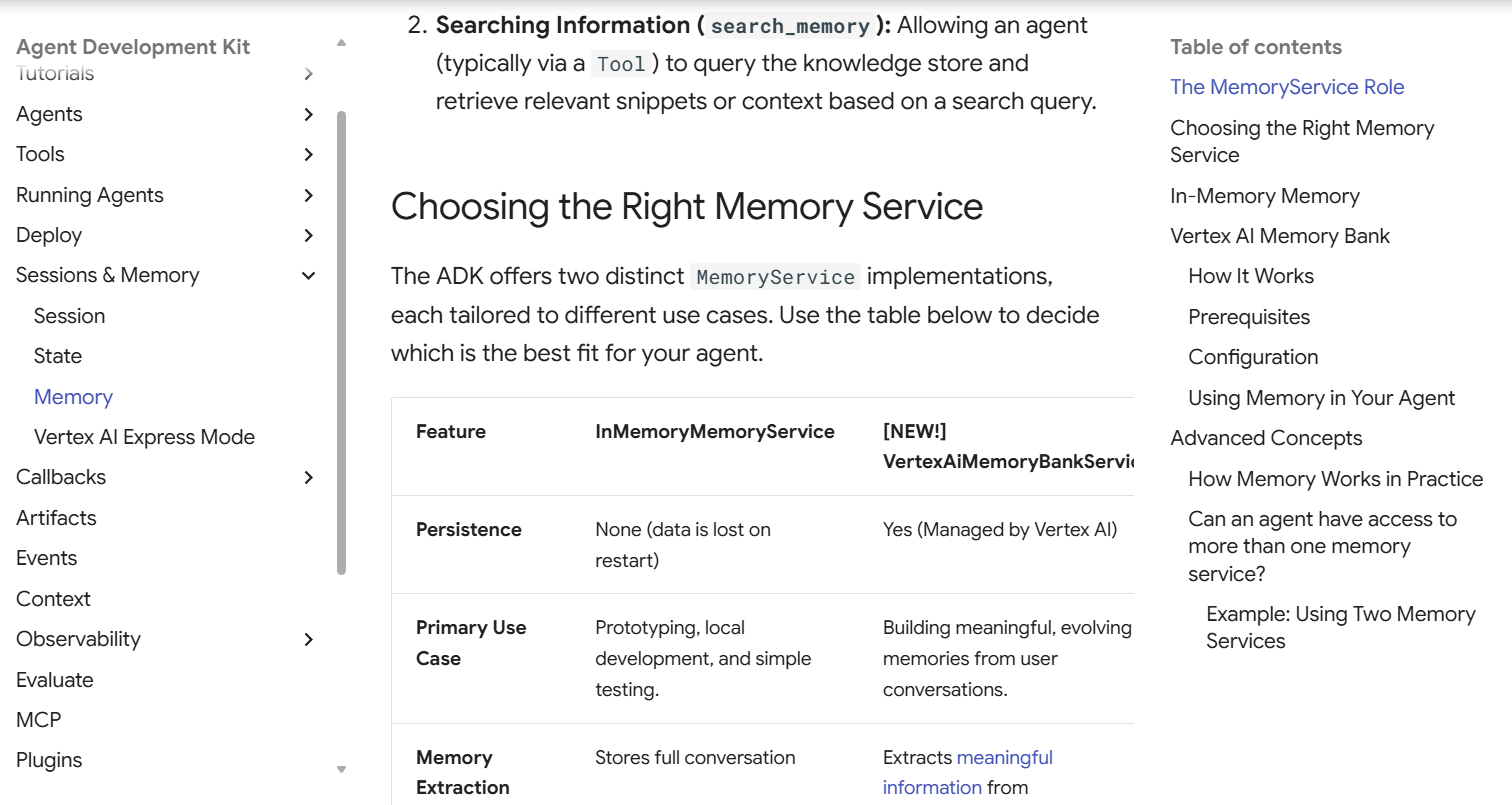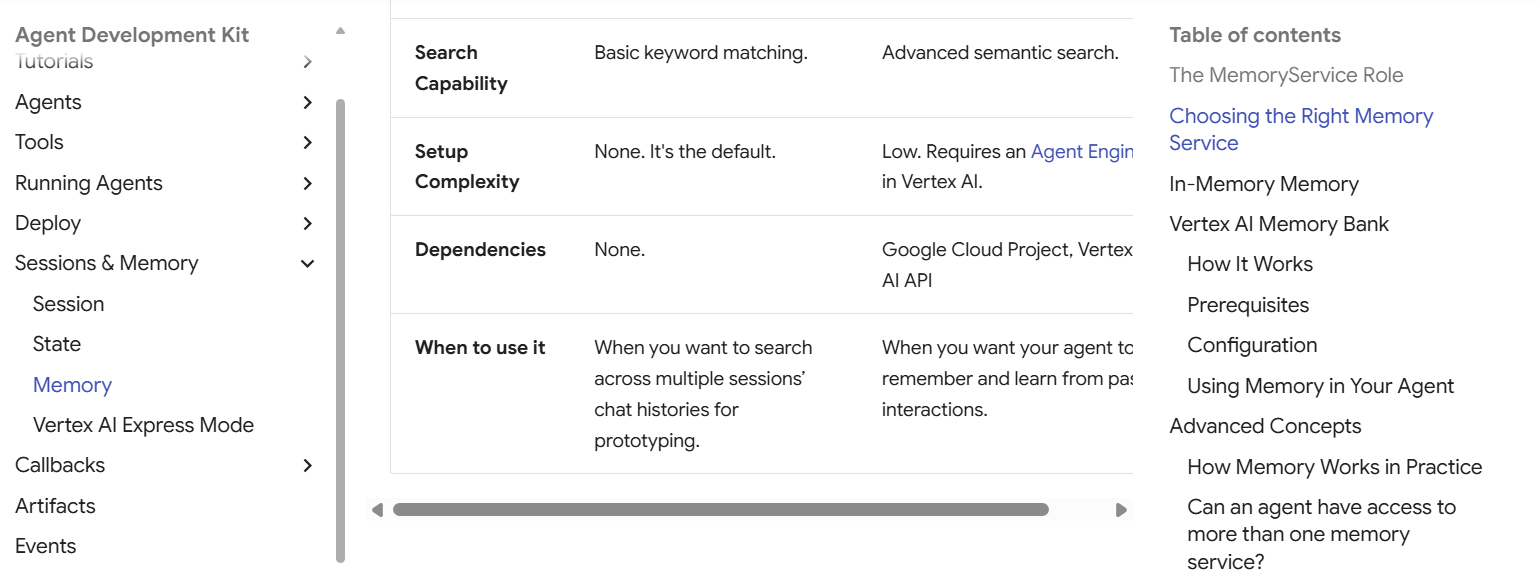
<br>

### `In-Memory Memory`

The `InMemoryMemoryService` stores session information in the application's memory and performs basic keyword matching for searches. It requires no setup and is best for prototyping and simple testing scenarios where persistence isn't required.

```Python
from google.adk.memory import InMemoryMemoryService
memory_service = InMemoryMemoryService()
```

---

**Example: Adding and Searching Memory**

> This example demonstrates the basic flow using the InMemoryMemoryService for simplicity.

```Python
import asyncio
from google.adk.agents import LlmAgent
from google.adk.sessions import InMemorySessionService, Session
from google.adk.memory import InMemoryMemoryService # Import MemoryService
from google.adk.runners import Runner
from google.adk.tools import load_memory # Tool to query memory
from google.genai.types import Content, Part

# --- Constants ---
APP_NAME = "memory_example_app"
USER_ID = "mem_user"
MODEL = "gemini-2.0-flash" # Use a valid model

# --- Agent Definitions ---
# Agent 1: Simple agent to capture information
info_capture_agent = LlmAgent(
    model=MODEL,
    name="InfoCaptureAgent",
    instruction="Acknowledge the user's statement.",
)

# Agent 2: Agent that can use memory
memory_recall_agent = LlmAgent(
    model=MODEL,
    name="MemoryRecallAgent",
    instruction="Answer the user's question. Use the 'load_memory' tool "
                "if the answer might be in past conversations.",
    tools=[load_memory] # Give the agent the tool
)

# --- Services ---
# Services must be shared across runners to share state and memory
session_service = InMemorySessionService()
memory_service = InMemoryMemoryService() # Use in-memory for demo

async def run_scenario():
    # --- Scenario ---

    # Turn 1: Capture some information in a session
    print("--- Turn 1: Capturing Information ---")
    runner1 = Runner(
        # Start with the info capture agent
        agent=info_capture_agent,
        app_name=APP_NAME,
        session_service=session_service,
        memory_service=memory_service # Provide the memory service to the Runner
    )
    session1_id = "session_info"
    await runner1.session_service.create_session(app_name=APP_NAME, user_id=USER_ID, session_id=session1_id)
    user_input1 = Content(parts=[Part(text="My favorite project is Project Alpha.")], role="user")

    # Run the agent
    final_response_text = "(No final response)"
    async for event in runner1.run_async(user_id=USER_ID, session_id=session1_id, new_message=user_input1):
        if event.is_final_response() and event.content and event.content.parts:
            final_response_text = event.content.parts[0].text
    print(f"Agent 1 Response: {final_response_text}")

    # Get the completed session
    completed_session1 = await runner1.session_service.get_session(app_name=APP_NAME, user_id=USER_ID, session_id=session1_id)

    # Add this session's content to the Memory Service
    print("\n--- Adding Session 1 to Memory ---")
    await memory_service.add_session_to_memory(completed_session1)
    print("Session added to memory.")

    # Turn 2: Recall the information in a new session
    print("\n--- Turn 2: Recalling Information ---")
    runner2 = Runner(
        # Use the second agent, which has the memory tool
        agent=memory_recall_agent,
        app_name=APP_NAME,
        session_service=session_service, # Reuse the same service
        memory_service=memory_service   # Reuse the same service
    )
    session2_id = "session_recall"
    await runner2.session_service.create_session(app_name=APP_NAME, user_id=USER_ID, session_id=session2_id)
    user_input2 = Content(parts=[Part(text="What is my favorite project?")], role="user")

    # Run the second agent
    final_response_text_2 = "(No final response)"
    async for event in runner2.run_async(user_id=USER_ID, session_id=session2_id, new_message=user_input2):
        if event.is_final_response() and event.content and event.content.parts:
            final_response_text_2 = event.content.parts[0].text
    print(f"Agent 2 Response: {final_response_text_2}")

# To run this example, you can use the following snippet:
# asyncio.run(run_scenario())

# await run_scenario()
```
---

**Example: Using Two Memory Services**
> Here’s how you could implement that in your agent's code:
```Python
from google.adk.agents import Agent
from google.adk.memory import InMemoryMemoryService, VertexAiMemoryBankService
from google.genai import types

class MultiMemoryAgent(Agent):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

        self.memory_service = InMemoryMemoryService()
        # Manually instantiate a second memory service for document lookups
        self.vertexai_memorybank_service = VertexAiMemoryBankService(
            project="PROJECT_ID",
            location="LOCATION",
            agent_engine_id="AGENT_ENGINE_ID"
        )

    async def run(self, request: types.Content, **kwargs) -> types.Content:
        user_query = request.parts[0].text

        # 1. Search conversational history using the framework-provided memory
        #    (This would be InMemoryMemoryService if configured)
        conversation_context = await self.memory_service.search_memory(query=user_query)

        # 2. Search the document knowledge base using the manually created service
        document_context = await self.vertexai_memorybank_service.search_memory(query=user_query)

        # Combine the context from both sources to generate a better response
        prompt = "From our past conversations, I remember:\n"
        prompt += f"{conversation_context.memories}\n\n"
        prompt += "From the technical manuals, I found:\n"
        prompt += f"{document_context.memories}\n\n"
        prompt += f"Based on all this, here is my answer to '{user_query}':"

        return await self.llm.generate_content_async(prompt)
```


---